# 1. Lý do chọn đề tài 
Trong ngành hàng không, động cơ Turbofan engine là bộ phận quan trọng, có giá trị kinh tế cao và ảnh hưởng trực tiếp đến độ an toàn bay. Quá trình vận hành lâu dài dưới nhiều điều kiện môi trường và tải khác nhau khiến động cơ dần bị hao mòn, suy giảm hiệu suất và có nguy cơ xảy ra hỏng hóc nếu không được theo dõi kịp thời. Việc giám sát tình trạng hoạt động và dự đoán mức độ hao mòn của động cơ đóng vai trò then chốt trong công tác bảo trì, giúp phát hiện sớm các dấu hiệu bất thường, giảm thiểu rủi ro sự cố nghiêm trọng và tối ưu chi phí khai thác. Bên cạnh đó, các hệ thống động cơ hiện đại thường được trang bị nhiều cảm biến ghi nhận dữ liệu vận hành liên tục, tạo điều kiện thuận lợi cho việc phân tích và đánh giá tình trạng kỹ thuật. Chính vì vậy, đề tài “Giám sát và dự đoán hao mòn động cơ Turbofan” được lựa chọn nhằm nghiên cứu và xây dựng phương pháp theo dõi tình trạng động cơ, góp phần nâng cao độ an toàn, độ tin cậy và hiệu quả vận hành trong thực tế.

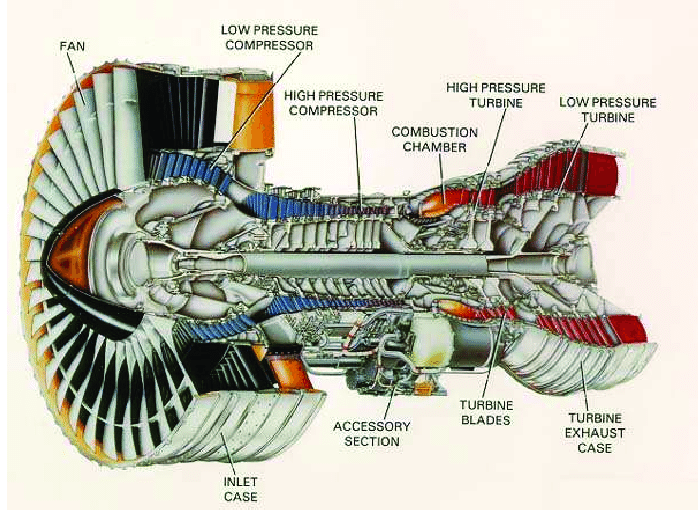



1. Reconstruction Error (quan trọng nhất)
𝑀
𝑆
𝐸
=
1
𝑛
∑
(
𝑥
𝑖
−
𝑥
𝑖
^
)
2
MSE=
n
1
	​

∑(x
i
	​

−
x
i
	​

^
	​

)
2

Ý nghĩa
→ đo độ khác giữa dữ liệu thật và dữ liệu tái tạo

Nếu error tăng mạnh
→ hệ thống bắt đầu mất ổn định

2. Reconstruction Error Trend

Phân tích error theo thời gian (cycle)

Cycle	Error
1	0.002
20	0.003
60	0.006
90	0.02

Nếu error tăng dần
→ engine đang degrade.

3. Detection Delay (rất hay cho turbofan)
𝐷
𝑒
𝑙
𝑎
𝑦
=
𝑡
𝑑
𝑒
𝑡
𝑒
𝑐
𝑡
−
𝑡
𝑡
𝑟
𝑢
𝑒
Delay=t
detect
	​

−t
true
	​

Engine	True degradation	Detect	Delay
1	120	125	5
2	90	100	10

Delay càng nhỏ → phát hiện càng sớm.

4. Health Index Trend

Có thể tạo

𝐻
𝐼
=
1
−
𝑛
𝑜
𝑟
𝑚
𝑎
𝑙
𝑖
𝑧
𝑒
𝑑
(
𝑒
𝑟
𝑟
𝑜
𝑟
)
HI=1−normalized(error)
Cycle	Health Index
1	1.0
40	0.95
80	0.7
100	0.4

HI giảm → hệ thống mất ổn định.

# 2. Tổng quan về bộ dữ liệu 
Link dataset: https://www.kaggle.com/datasets/behrad3d/nasa-cmaps/data
 
 Bộ dữ liệu được sử dụng trong đề tài là bộ dữ liệu mô phỏng hỏng hóc động cơ do NASA công bố trong khuôn khổ nghiên cứu về dự đoán tuổi thọ thiết bị. Dữ liệu được tạo ra từ mô hình mô phỏng động cơ Turbofan engine trong điều kiện vận hành thực tế, với mục tiêu nghiên cứu quá trình suy giảm hiệu suất cho đến khi xảy ra hỏng hóc hoàn toàn.

Mỗi bộ dữ liệu bao gồm nhiều chuỗi thời gian đa biến (multivariate time series), trong đó mỗi chuỗi tương ứng với một động cơ riêng biệt. Mỗi động cơ bắt đầu hoạt động trong trạng thái bình thường, sau đó xuất hiện lỗi và mức độ hư hỏng tăng dần theo thời gian cho đến khi hệ thống ngừng hoạt động (trong tập huấn luyện). Đối với tập kiểm tra, dữ liệu dừng lại trước khi động cơ hỏng hoàn toàn, và mục tiêu là xác định số chu kỳ vận hành còn lại trước khi xảy ra hỏng hóc.

Dữ liệu được chia thành bốn tập chính:

FD001: 1 điều kiện vận hành, 1 chế độ lỗi

FD002: 6 điều kiện vận hành, 1 chế độ lỗi

FD003: 1 điều kiện vận hành, 2 chế độ lỗi

FD004: 6 điều kiện vận hành, 2 chế độ lỗi

Mỗi tập bao gồm:

Tập huấn luyện (train)

Tập kiểm tra (test)

File giá trị tuổi thọ còn lại thực tế (RUL) cho tập test

Mỗi dòng dữ liệu gồm 26 cột, tương ứng với:

ID động cơ

Chu kỳ hoạt động (cycle)
3–5. Ba thông số điều kiện vận hành (operational settings)
6–26. Các giá trị đo từ cảm biến

Dữ liệu có đặc điểm:

Là chuỗi thời gian dài theo từng động cơ

Có nhiễu cảm biến

Có sự thay đổi điều kiện vận hành

Thể hiện rõ quá trình suy giảm hiệu suất theo thời gian

Nhờ những đặc điểm này, bộ dữ liệu phù hợp cho nghiên cứu giám sát tình trạng và dự đoán mức độ hao mòn của động cơ trong môi trường gần với thực tế vận hành công nghiệp.

# 3. Import các thư viện cần thiết 


In [1]:
# ===== Core =====
import os
import time
import datetime
import pickle
import joblib


import numpy as np
import pandas as pd

# ===== Visualization (EDA / dashboard) =====
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# ===== Preprocessing / split =====
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# ===== Metrics =====
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ===== RUL models =====
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# ===== Anomaly / instability models =====
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

# ===== Deep learning (LSTM + LSTM Autoencoder) =====
import tensorflow as tf


# ===== Flask backend =====
from flask import Flask, render_template, request, jsonify
from flask_cors import CORS

# ===== Email alerts (.env + SMTP) =====
from dotenv import load_dotenv
import smtplib
from email.message import EmailMessage

# 4. EDA và Huấn luyện các mô hình cho chức năng dự đoán tuổi thọ 

## 4.1 FD001

## 4.1.1 Đọc file dữ liệu và xử lý đơn giản

In [2]:
import pandas as pd

df = pd.read_csv("../data_csv/train_FD001.csv")

print(df.head())

   engine_id  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  \
0          1      1       -0.0007       -0.0004         100.0    518.67   
1          1      2        0.0019       -0.0003         100.0    518.67   
2          1      3       -0.0043        0.0003         100.0    518.67   
3          1      4        0.0007        0.0000         100.0    518.67   
4          1      5       -0.0019       -0.0002         100.0    518.67   

   sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  \
0    641.82   1589.70   1400.60     14.62  ...     521.66    2388.02   
1    642.15   1591.82   1403.14     14.62  ...     522.28    2388.07   
2    642.35   1587.99   1404.20     14.62  ...     522.42    2388.03   
3    642.35   1582.79   1401.87     14.62  ...     522.86    2388.08   
4    642.37   1582.85   1406.22     14.62  ...     522.19    2388.04   

   sensor_14  sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  \
0    8138.62     8.4195       0.03        392

| Nhóm                | Tên cột      | Viết tắt  | Ý nghĩa                                                              |
| ------------------- | ------------ | --------- | -------------------------------------------------------------------- |
| Engine info         | engine_id    | Engine ID | Mã định danh của động cơ. Mỗi động cơ có nhiều chu kỳ hoạt động.     |
| Engine info         | cycle        | Cycle     | Chu kỳ hoạt động của động cơ theo thời gian (1,2,3...).              |
| Operating condition | op_setting_1 | OS1       | Tham số điều kiện vận hành của động cơ (ví dụ chế độ hoạt động).     |
| Operating condition | op_setting_2 | OS2       | Tham số điều kiện vận hành thứ hai của động cơ.                      |
| Operating condition | op_setting_3 | OS3       | Tham số điều kiện vận hành thứ ba (thường ổn định trong FD001).      |
| Sensor              | sensor_1     | S1        | Cảm biến số 1 của động cơ (đo thông số vật lý như nhiệt độ/áp suất). |
| Sensor              | sensor_2     | S2        | Cảm biến số 2 (thường liên quan nhiệt độ compressor).                |
| Sensor              | sensor_3     | S3        | Cảm biến số 3 (áp suất hoặc nhiệt độ dòng khí).                      |
| Sensor              | sensor_4     | S4        | Cảm biến số 4 (nhiệt độ turbine).                                    |
| Sensor              | sensor_5     | S5        | Cảm biến số 5 (một thông số vận hành của hệ thống).                  |
| Sensor              | sensor_6     | S6        | Cảm biến số 6 đo trạng thái của hệ thống.                            |
| Sensor              | sensor_7     | S7        | Cảm biến số 7 (thường liên quan airflow).                            |
| Sensor              | sensor_8     | S8        | Cảm biến số 8 đo một tham số của compressor.                         |
| Sensor              | sensor_9     | S9        | Cảm biến số 9 đo trạng thái hệ thống turbine.                        |
| Sensor              | sensor_10    | S10       | Cảm biến số 10 đo hiệu suất hệ thống.                                |
| Sensor              | sensor_11    | S11       | Cảm biến số 11 (thường dùng trong dự đoán suy giảm).                 |
| Sensor              | sensor_12    | S12       | Cảm biến số 12 đo trạng thái compressor/turbine.                     |
| Sensor              | sensor_13    | S13       | Cảm biến số 13 đo hiệu suất turbine.                                 |
| Sensor              | sensor_14    | S14       | Cảm biến số 14 đo trạng thái nhiệt độ hoặc áp suất.                  |
| Sensor              | sensor_15    | S15       | Cảm biến số 15 (liên quan fuel flow).                                |
| Sensor              | sensor_16    | S16       | Cảm biến số 16 đo trạng thái hệ thống phụ.                           |
| Sensor              | sensor_17    | S17       | Cảm biến số 17 đo thông số hoạt động động cơ.                        |
| Sensor              | sensor_18    | S18       | Cảm biến số 18 đo áp suất/hiệu suất.                                 |
| Sensor              | sensor_19    | S19       | Cảm biến số 19 đo trạng thái hoạt động chung.                        |
| Sensor              | sensor_20    | S20       | Cảm biến số 20 đo nhiệt độ khí xả.                                   |
| Sensor              | sensor_21    | S21       | Cảm biến số 21 đo nhiệt độ khí xả/turbine.                           |


Trong dataset NASA Turbofan (CMAPSS), NASA không công bố chính xác tên vật lý của từng sensor, nhưng trong các paper PHM08 / Predictive Maintenance người ta thường gán ý nghĩa kỹ thuật gần đúng cho từng sensor.

| Sensor    | Tên chi tiết (English)             | Viết tắt | Ý nghĩa                           |
| --------- | ---------------------------------- | -------- | --------------------------------- |
| sensor_1  | Total Temperature at Fan Inlet     | T2       | Nhiệt độ tổng tại cửa vào quạt    |
| sensor_2  | Total Temperature at LPC Outlet    | T24      | Nhiệt độ sau máy nén áp suất thấp |
| sensor_3  | Total Temperature at HPC Outlet    | T30      | Nhiệt độ sau máy nén áp suất cao  |
| sensor_4  | Total Temperature at LPT Outlet    | T50      | Nhiệt độ sau turbine áp suất thấp |
| sensor_5  | Pressure at Fan Inlet              | P2       | Áp suất tại cửa vào quạt          |
| sensor_6  | Total Pressure at Bypass Duct      | P15      | Áp suất dòng bypass               |
| sensor_7  | Total Pressure at HPC Outlet       | P30      | Áp suất sau máy nén áp suất cao   |
| sensor_8  | Physical Fan Speed                 | Nf       | Tốc độ quay của quạt              |
| sensor_9  | Physical Core Speed                | Nc       | Tốc độ quay lõi động cơ           |
| sensor_10 | Engine Pressure Ratio              | EPR      | Tỷ lệ áp suất động cơ             |
| sensor_11 | Static Pressure at HPC Outlet      | Ps30     | Áp suất tĩnh sau compressor       |
| sensor_12 | Ratio of Fuel Flow to Ps30         | phi      | Tỷ lệ nhiên liệu                  |
| sensor_13 | Corrected Fan Speed                | Nf_d     | Tốc độ quạt đã hiệu chỉnh         |
| sensor_14 | Corrected Core Speed               | Nc_d     | Tốc độ lõi đã hiệu chỉnh          |
| sensor_15 | Bypass Ratio                       | BPR      | Tỷ lệ dòng bypass                 |
| sensor_16 | Burner Fuel-Air Ratio              | FAR      | Tỷ lệ nhiên liệu / không khí      |
| sensor_17 | Bleed Enthalpy                     | h_bleed  | Nhiệt lượng khí bleed             |
| sensor_18 | Bleed Air Pressure                 | P_bleed  | Áp suất khí bleed                 |
| sensor_19 | High Pressure Turbine Cooling Flow | HPT_flow | Lưu lượng làm mát turbine cao     |
| sensor_20 | Low Pressure Turbine Cooling Flow  | LPT_flow | Lưu lượng làm mát turbine thấp    |
| sensor_21 | Exhaust Gas Temperature            | EGT      | Nhiệt độ khí xả                   |


tôi sẽ đổi tên thành các cột này để có thể trực quan và dễ giải thích hơn

In [3]:
df = df.rename(columns={
"sensor_1":"fan_inlet_temperature_T2",
"sensor_2":"compressor_LPC_outlet_temp_T24",
"sensor_3":"compressor_HPC_outlet_temp_T30",
"sensor_4":"turbine_LPT_outlet_temp_T50",
"sensor_5":"fan_inlet_pressure_P2",
"sensor_6":"bypass_duct_pressure_P15",
"sensor_7":"HPC_outlet_pressure_P30",
"sensor_8":"fan_speed_Nf",
"sensor_9":"core_speed_Nc",
"sensor_10":"engine_pressure_ratio_EPR",
"sensor_11":"static_pressure_HPC_Ps30",
"sensor_12":"fuel_flow_ratio_phi",
"sensor_13":"corrected_fan_speed",
"sensor_14":"corrected_core_speed",
"sensor_15":"bypass_ratio_BPR",
"sensor_16":"fuel_air_ratio_FAR",
"sensor_17":"bleed_air_enthalpy",
"sensor_18":"bleed_air_pressure",
"sensor_19":"HPT_cooling_flow",
"sensor_20":"LPT_cooling_flow",
"sensor_21":"exhaust_gas_temperature_EGT"
})
df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,fan_inlet_temperature_T2,compressor_LPC_outlet_temp_T24,compressor_HPC_outlet_temp_T30,turbine_LPT_outlet_temp_T50,fan_inlet_pressure_P2,...,fuel_flow_ratio_phi,corrected_fan_speed,corrected_core_speed,bypass_ratio_BPR,fuel_air_ratio_FAR,bleed_air_enthalpy,bleed_air_pressure,HPT_cooling_flow,LPT_cooling_flow,exhaust_gas_temperature_EGT
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
df.describe()


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,fan_inlet_temperature_T2,compressor_LPC_outlet_temp_T24,compressor_HPC_outlet_temp_T30,turbine_LPT_outlet_temp_T50,fan_inlet_pressure_P2,...,fuel_flow_ratio_phi,corrected_fan_speed,corrected_core_speed,bypass_ratio_BPR,fuel_air_ratio_FAR,bleed_air_enthalpy,bleed_air_pressure,HPT_cooling_flow,LPT_cooling_flow,exhaust_gas_temperature_EGT
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15,...,0.737553,0.071919,19.076176,0.037505,1.387812e-17,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


bây giờ ta sẽ tạo nhãn RUL cho bộ dữ liệu 

In [5]:
max_cycle = df.groupby('engine_id')['cycle'].max()

# gắn lại vào dataframe
df['max_cycle'] = df['engine_id'].map(max_cycle)

# tính RUL
df['RUL'] = df['max_cycle'] - df['cycle']

# xoá cột trung gian
df = df.drop(columns=['max_cycle'])

# Giới hạn RUL tối đa = 125
df['RUL'] = df['RUL'].clip(upper=125)

df.head()


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,fan_inlet_temperature_T2,compressor_LPC_outlet_temp_T24,compressor_HPC_outlet_temp_T30,turbine_LPT_outlet_temp_T50,fan_inlet_pressure_P2,...,corrected_fan_speed,corrected_core_speed,bypass_ratio_BPR,fuel_air_ratio_FAR,bleed_air_enthalpy,bleed_air_pressure,HPT_cooling_flow,LPT_cooling_flow,exhaust_gas_temperature_EGT,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125


In [6]:
df.head(100)

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,fan_inlet_temperature_T2,compressor_LPC_outlet_temp_T24,compressor_HPC_outlet_temp_T30,turbine_LPT_outlet_temp_T50,fan_inlet_pressure_P2,...,corrected_fan_speed,corrected_core_speed,bypass_ratio_BPR,fuel_air_ratio_FAR,bleed_air_enthalpy,bleed_air_pressure,HPT_cooling_flow,LPT_cooling_flow,exhaust_gas_temperature_EGT,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1,96,-0.0034,0.0001,100.0,518.67,642.19,1584.07,1395.16,14.62,...,2388.06,8130.69,8.4311,0.03,392,2388,100.0,38.88,23.3255,96
96,1,97,0.0035,-0.0003,100.0,518.67,642.07,1595.77,1407.81,14.62,...,2388.06,8128.74,8.4105,0.03,392,2388,100.0,39.01,23.2963,95
97,1,98,0.0006,0.0004,100.0,518.67,642.00,1591.11,1404.56,14.62,...,2388.06,8127.89,8.4012,0.03,391,2388,100.0,38.96,23.2554,94
98,1,99,-0.0005,-0.0000,100.0,518.67,642.46,1592.73,1406.13,14.62,...,2388.10,8131.77,8.4481,0.03,393,2388,100.0,38.82,23.2323,93


In [7]:
df.std()

engine_id                         2.922763e+01
cycle                             6.888099e+01
op_setting_1                      2.187313e-03
op_setting_2                      2.930621e-04
op_setting_3                      0.000000e+00
fan_inlet_temperature_T2          0.000000e+00
compressor_LPC_outlet_temp_T24    5.000533e-01
compressor_HPC_outlet_temp_T30    6.131150e+00
turbine_LPT_outlet_temp_T50       9.000605e+00
fan_inlet_pressure_P2             1.776400e-15
bypass_duct_pressure_P15          1.388985e-03
HPC_outlet_pressure_P30           8.850923e-01
fan_speed_Nf                      7.098548e-02
core_speed_Nc                     2.208288e+01
engine_pressure_ratio_EPR         0.000000e+00
static_pressure_HPC_Ps30          2.670874e-01
fuel_flow_ratio_phi               7.375534e-01
corrected_fan_speed               7.191892e-02
corrected_core_speed              1.907618e+01
bypass_ratio_BPR                  3.750504e-02
fuel_air_ratio_FAR                1.387812e-17
bleed_air_ent

 Các cột không có ý nghĩa cho model

Những cột có STD ≈ 0 gần như không thay đổi → model không học được gì.

| Feature                   | STD     | Nhận xét           |
| ------------------------- | ------- | ------------------ |
| op_setting_3              | 0       | ❌ luôn constant    |
| fan_inlet_temperature_T2  | 6.5e-11 | ❌ gần như constant |
| fan_inlet_pressure_P2     | 3.3e-12 | ❌ constant         |
| engine_pressure_ratio_EPR | 4.6e-13 | ❌ constant         |
| fuel_air_ratio_FAR        | 1.5e-14 | ❌ constant         |
| bleed_air_pressure        | 0       | ❌ constant         |
| HPT_cooling_flow          | 0       | ❌ constant         |


👉 Những cột này sẽ được drop khi train model.

## 4.1.2 EDA

### Trực quan hóa các cột với cột RUL

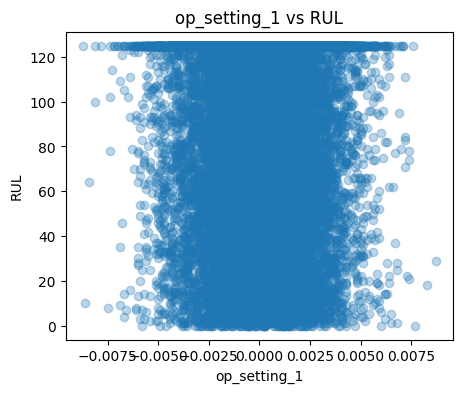

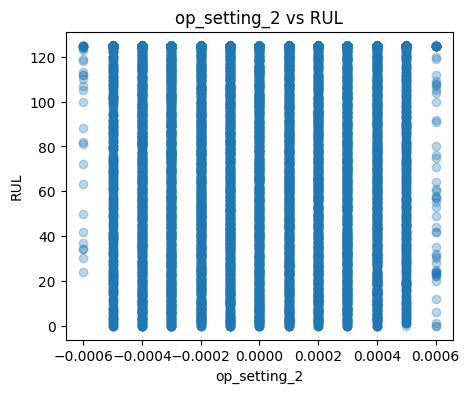

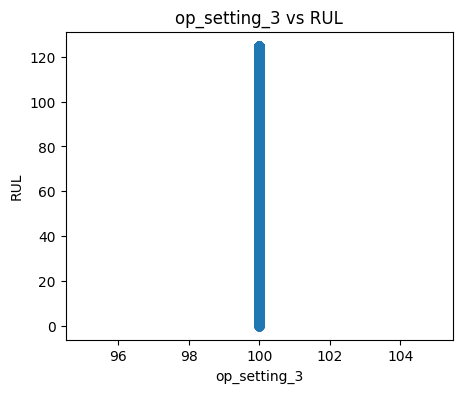

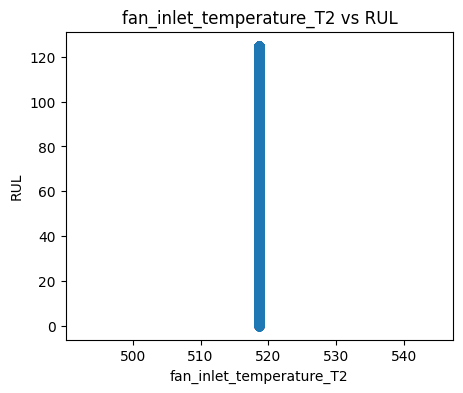

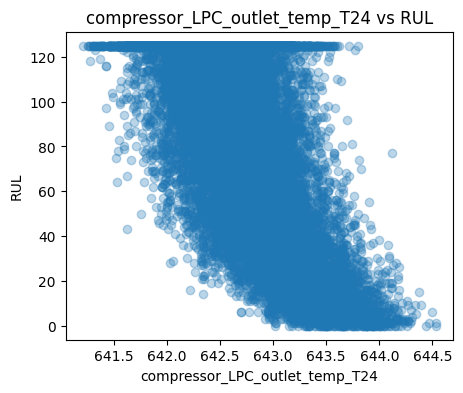

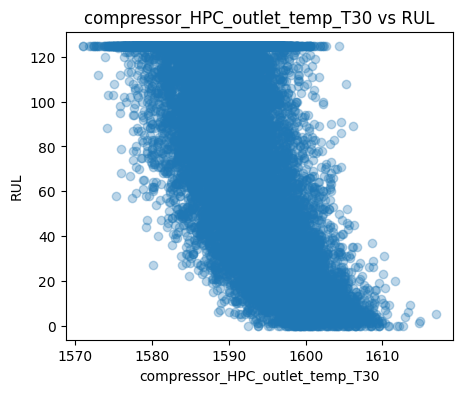

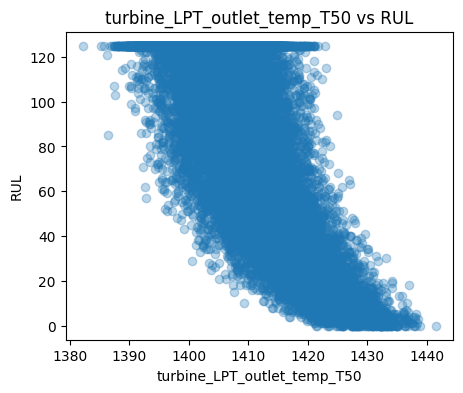

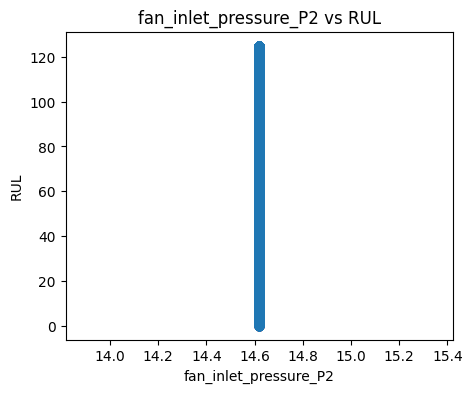

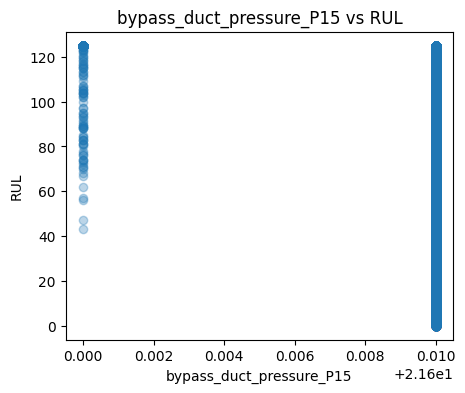

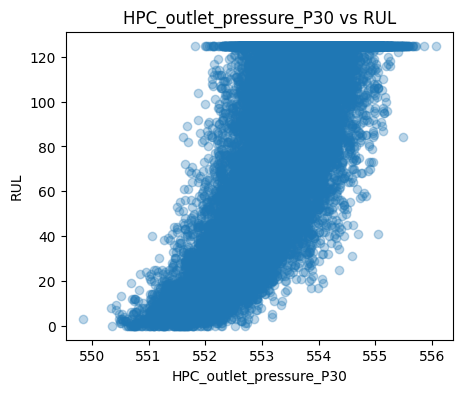

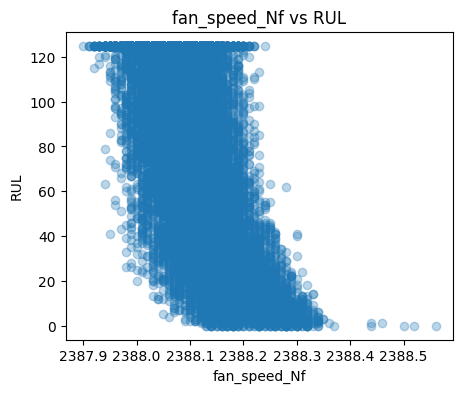

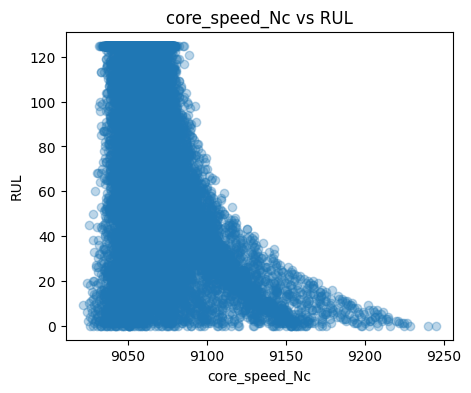

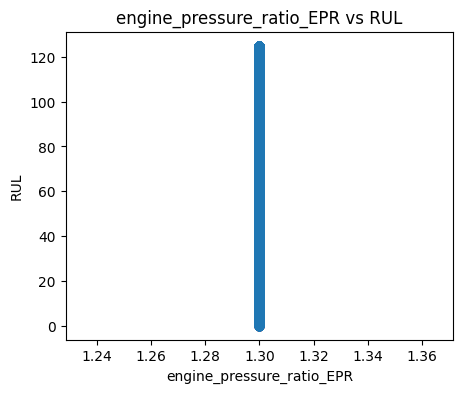

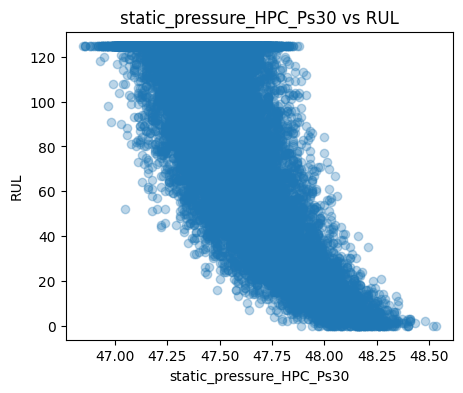

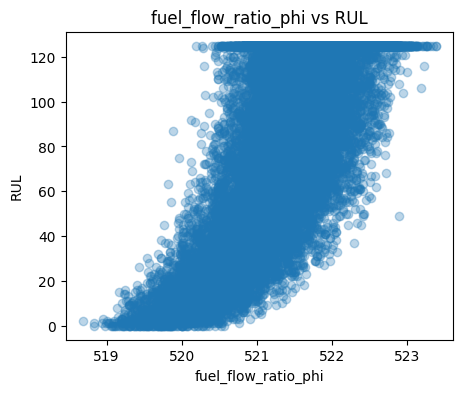

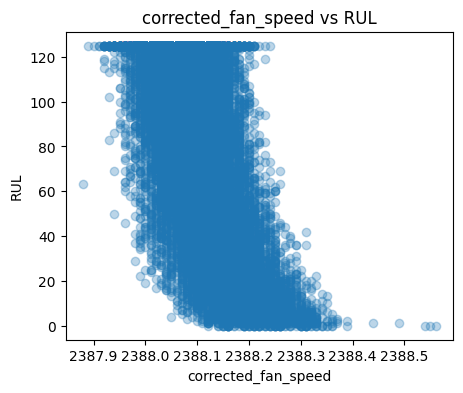

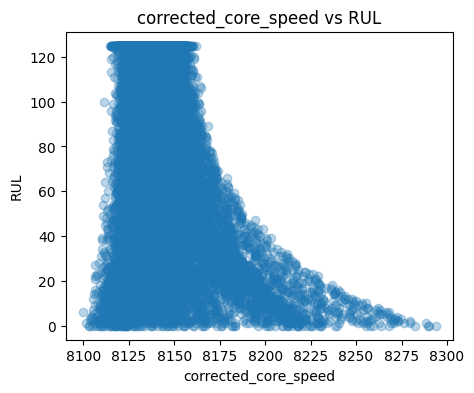

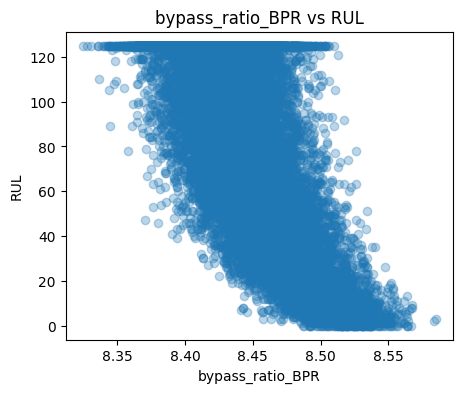

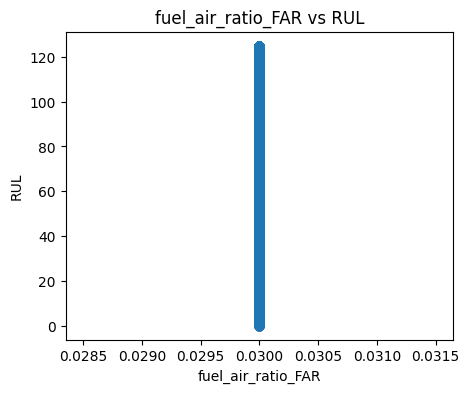

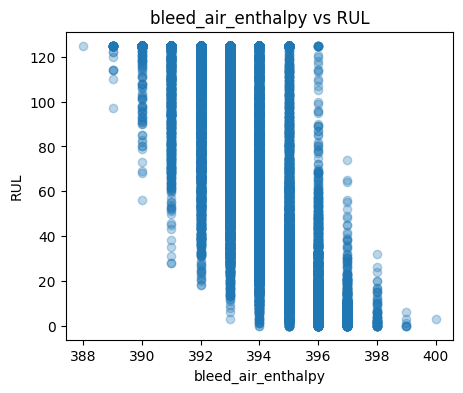

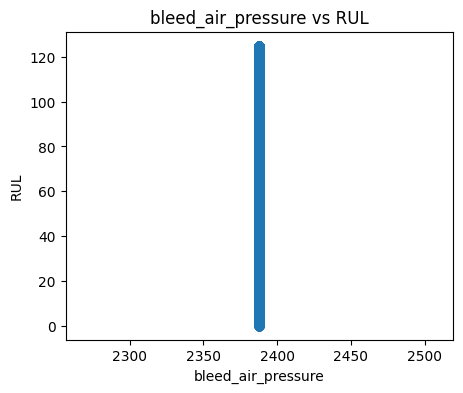

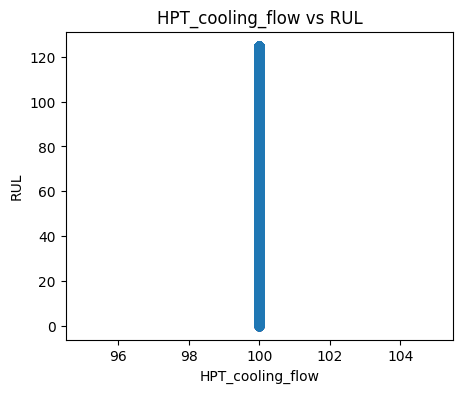

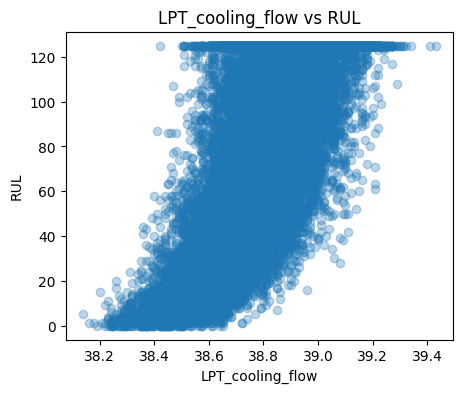

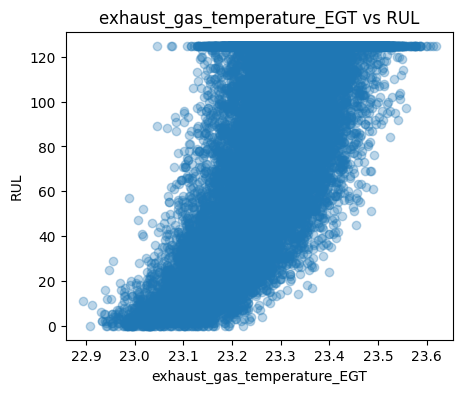

In [8]:

# Lấy tất cả cột trừ id và cycle
cols = [c for c in df.columns if c not in ['engine_id','cycle','RUL']]

for col in cols:
    
    plt.figure(figsize=(5,4))
    
    plt.scatter(df[col], df['RUL'], alpha=0.3)
    
    plt.xlabel(col)
    plt.ylabel('RUL')
    
    plt.title(f"{col} vs RUL")
    
    plt.show()

| Cột (Feature)                  | Mối quan hệ với RUL | Nhận xét                                                       |
| ------------------------------ | ------------------- | -------------------------------------------------------------- |
| op_setting_1                   | Yếu                 | Có biến động rất nhỏ, mối quan hệ với RUL không rõ ràng        |
| op_setting_2                   | Yếu                 | Phân bố gần như ngẫu nhiên theo RUL                            |
| op_setting_3                   | Không có            | Giá trị hằng (STD = 0), không có thông tin cho mô hình         |
| fan_inlet_temperature_T2       | Không có            | Giá trị gần như không thay đổi                                 |
| compressor_LPC_outlet_temp_T24 | Trung bình          | Có xu hướng thay đổi theo RUL nhưng chưa rõ rệt                |
| compressor_HPC_outlet_temp_T30 | Mạnh                | Biến đổi khá rõ khi RUL giảm, phản ánh sự suy giảm của động cơ |
| turbine_LPT_outlet_temp_T50    | Mạnh                | Xu hướng biến đổi rõ theo RUL, là sensor quan trọng            |
| fan_inlet_pressure_P2          | Không có            | Giá trị gần như constant                                       |
| bypass_duct_pressure_P15       | Yếu                 | Phân bố khá rải rác                                            |
| HPC_outlet_pressure_P30        | Trung bình          | Có mối liên hệ nhất định với RUL                               |
| fan_speed_Nf                   | Yếu                 | Phân tán nhiều, mối quan hệ chưa rõ                            |
| core_speed_Nc                  | Mạnh                | Thể hiện xu hướng rõ ràng khi động cơ suy giảm                 |
| engine_pressure_ratio_EPR      | Không có            | Gần như constant                                               |
| static_pressure_HPC_Ps30       | Trung bình          | Có sự thay đổi theo RUL                                        |
| fuel_flow_ratio_phi            | Trung bình          | Có xu hướng tăng/giảm theo RUL                                 |
| corrected_fan_speed            | Yếu                 | Biến động nhỏ                                                  |
| corrected_core_speed           | Mạnh                | Có xu hướng rõ theo RUL                                        |
| bypass_ratio_BPR               | Yếu                 | Phân bố khá ngẫu nhiên                                         |
| fuel_air_ratio_FAR             | Không có            | Giá trị gần như không thay đổi                                 |
| bleed_air_enthalpy             | Trung bình          | Có biến động theo chu kỳ hoạt động                             |
| bleed_air_pressure             | Không có            | Constant                                                       |
| HPT_cooling_flow               | Không có            | Constant                                                       |
| LPT_cooling_flow               | Yếu                 | Biến động nhỏ                                                  |
| exhaust_gas_temperature_EGT    | Trung bình          | Có mối liên hệ nhất định với RUL                               |


### Phân phối của các điều kiện vận hành


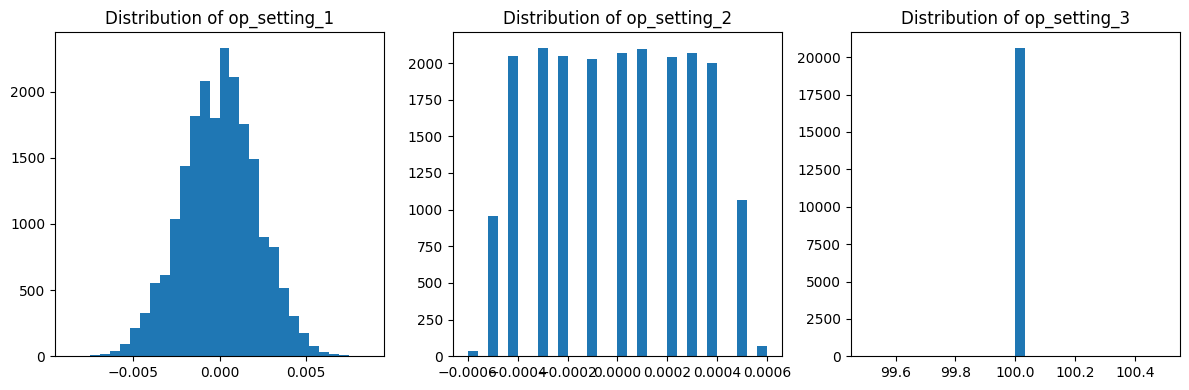

In [9]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(df['op_setting_1'], bins=30)
plt.title("Distribution of op_setting_1")

plt.subplot(1,3,2)
plt.hist(df['op_setting_2'], bins=30)
plt.title("Distribution of op_setting_2")

plt.subplot(1,3,3)
plt.hist(df['op_setting_3'], bins=30)
plt.title("Distribution of op_setting_3")

plt.tight_layout()
plt.show()

Phân tích phân phối của các biến operating settings cho thấy op_setting_1 có dạng phân phối gần chuẩn với mức dao động nhỏ, trong khi op_setting_2 thể hiện các giá trị rời rạc tương ứng với các chế độ vận hành khác nhau của động cơ. Ngược lại, op_setting_3 gần như không thay đổi và tập trung quanh giá trị 100, cho thấy biến này có thể không mang nhiều thông tin hữu ích cho quá trình dự đoán Remaining Useful Life (RUL).

### Điều kiện vận hành  theo cycle



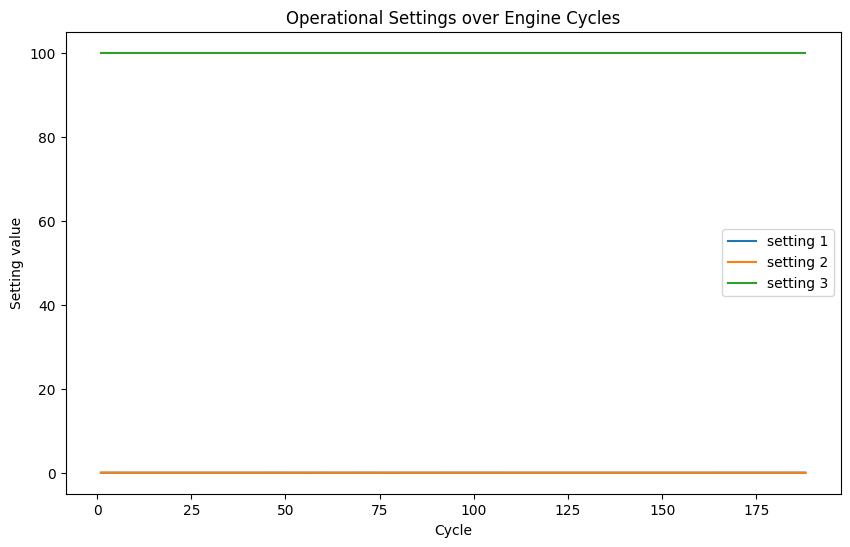

In [10]:
engine = df[df['engine_id']==6]

plt.figure(figsize=(10,6))

plt.plot(engine['cycle'], engine['op_setting_1'], label='setting 1')
plt.plot(engine['cycle'], engine['op_setting_2'], label='setting 2')
plt.plot(engine['cycle'], engine['op_setting_3'], label='setting 3')

plt.legend()
plt.xlabel("Cycle")
plt.ylabel("Setting value")
plt.title("Operational Settings over Engine Cycles")

plt.show()

### Phân tích phân phối các sensor 

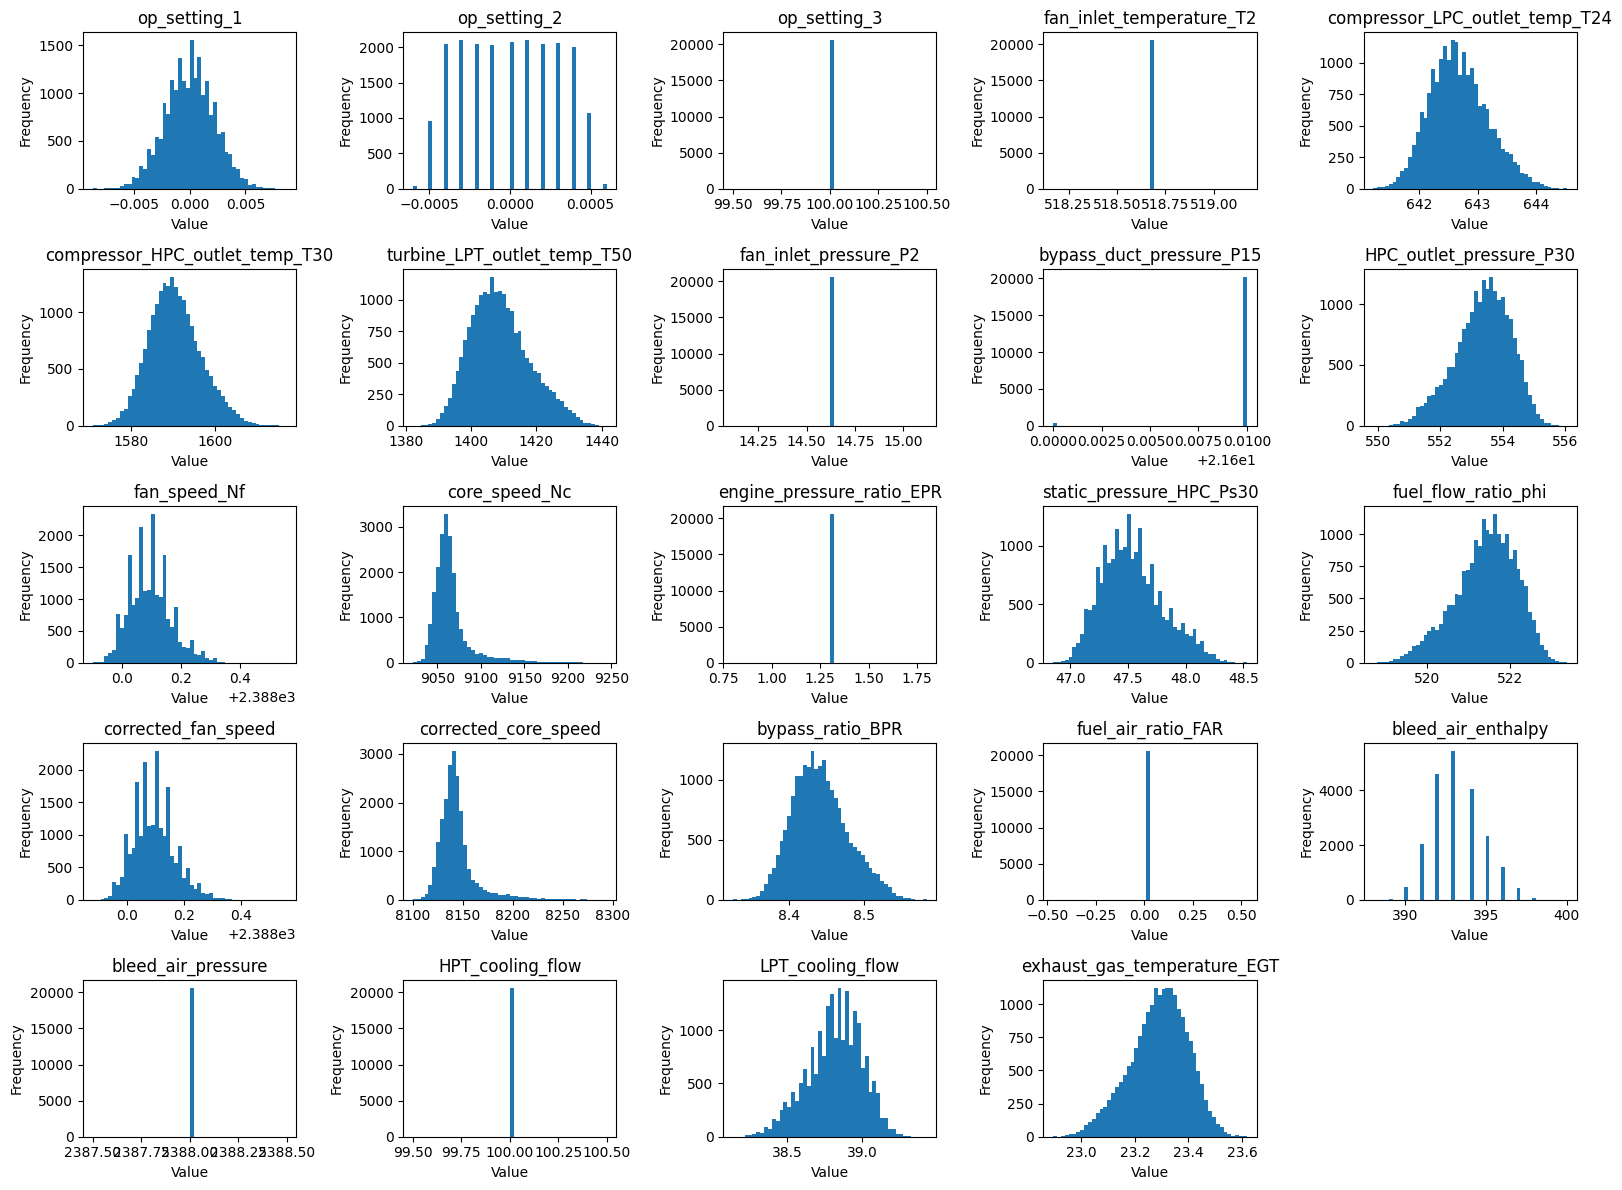

In [11]:
import matplotlib.pyplot as plt

# Lấy các cột sensor (bỏ id, cycle, RUL)
sensor_cols = [c for c in df.columns if c not in ['engine_id','cycle','RUL']]

plt.figure(figsize=(16,12))

for i, col in enumerate(sensor_cols, 1):
    
    plt.subplot(5,5,i)
    
    plt.hist(df[col], bins=50)
    
    plt.title(col)
    plt.xlabel("Value")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Phân tích xu hướng sụp đổ của các engine

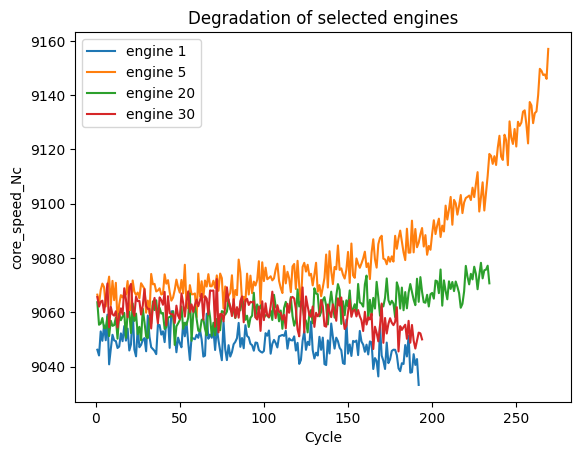

In [12]:
for i in [1,5,20,30]:
    temp = df[df['engine_id']==i]
    plt.plot(temp['cycle'], temp['core_speed_Nc'], label=f'engine {i}')

plt.legend()
plt.xlabel("Cycle")
plt.ylabel("core_speed_Nc")
plt.title("Degradation of selected engines")
plt.show()

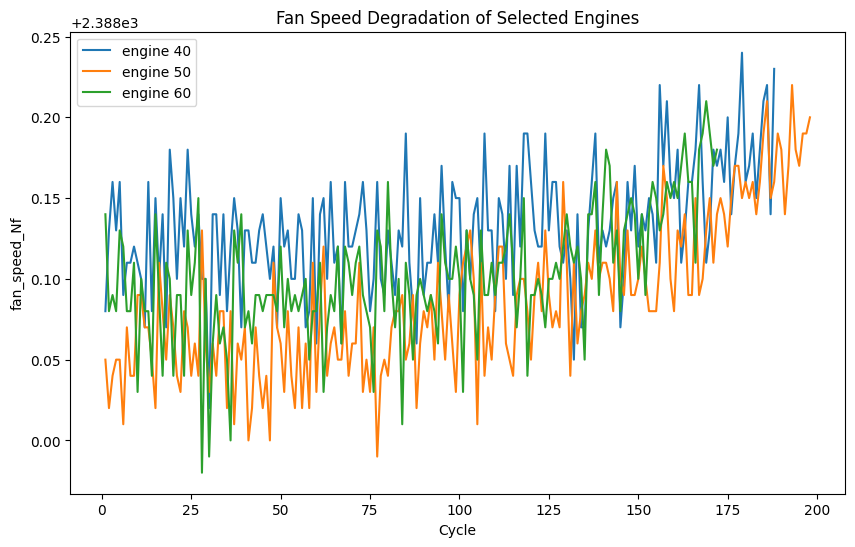

In [13]:
engines = [40,50,60]

plt.figure(figsize=(10,6))

for i in engines:
    temp = df[df['engine_id'] == i]
    plt.plot(temp['cycle'], temp['fan_speed_Nf'], label=f'engine {i}')

plt.legend()
plt.xlabel("Cycle")
plt.ylabel("fan_speed_Nf")  
plt.title("Fan Speed Degradation of Selected Engines")
plt.show()

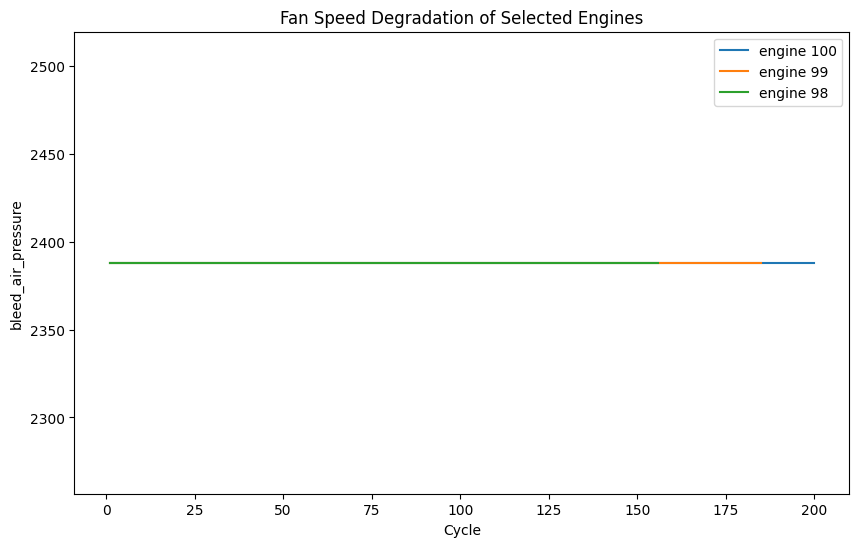

In [14]:
engines = [100,99,98]

plt.figure(figsize=(10,6))

for i in engines:
    temp = df[df['engine_id'] == i]
    plt.plot(temp['cycle'], temp['bleed_air_pressure'], label=f'engine {i}')

plt.legend()
plt.xlabel("Cycle")
plt.ylabel("bleed_air_pressure")
plt.title("Fan Speed Degradation of Selected Engines")
plt.show()

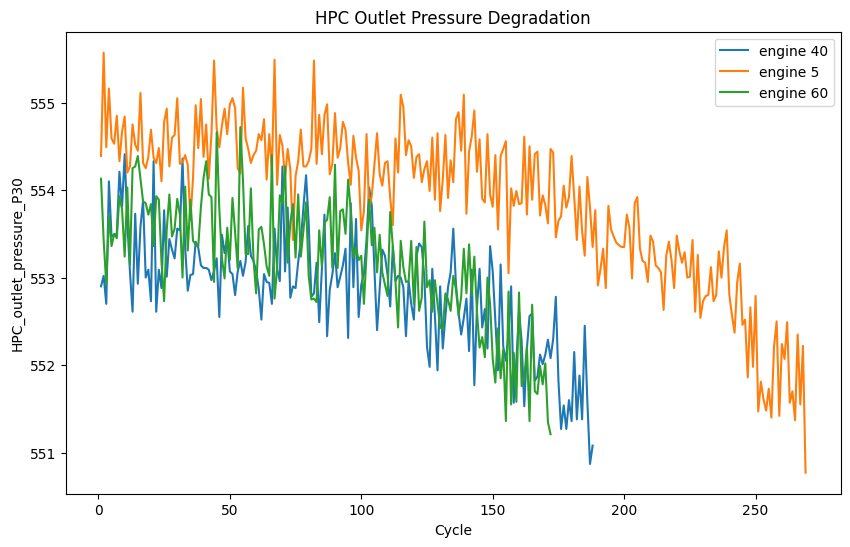

In [15]:
engines = [40,5,60]

plt.figure(figsize=(10,6))

for i in engines:
    temp = df[df['engine_id'] == i]
    plt.plot(temp['cycle'], temp['HPC_outlet_pressure_P30'], label=f'engine {i}')

plt.legend()
plt.xlabel("Cycle")
plt.ylabel("HPC_outlet_pressure_P30")
plt.title("HPC Outlet Pressure Degradation")

plt.show()

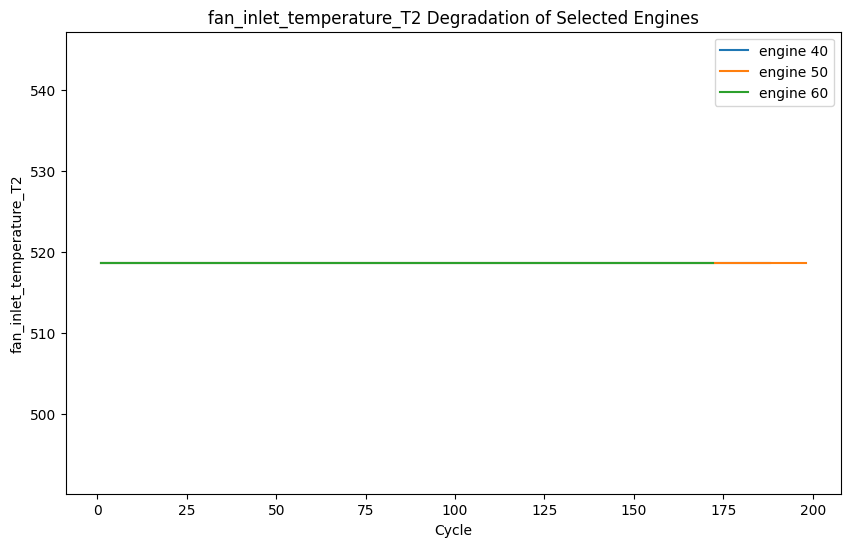

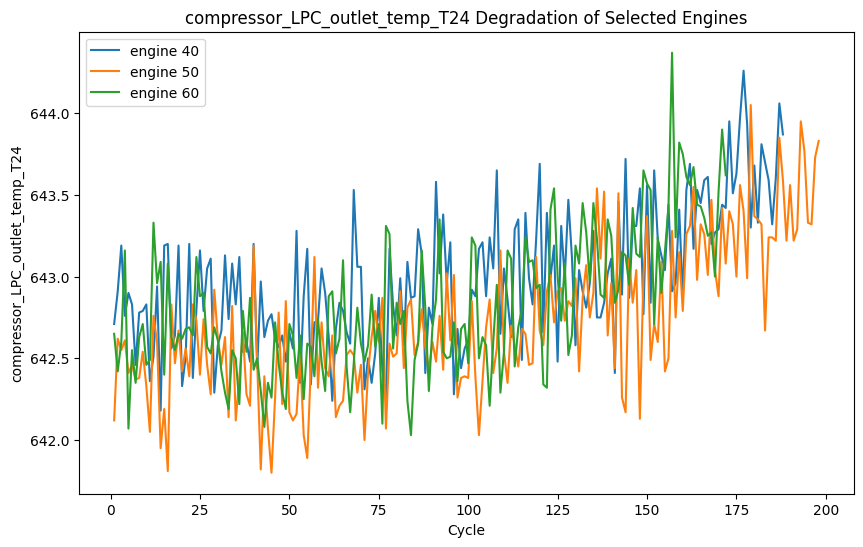

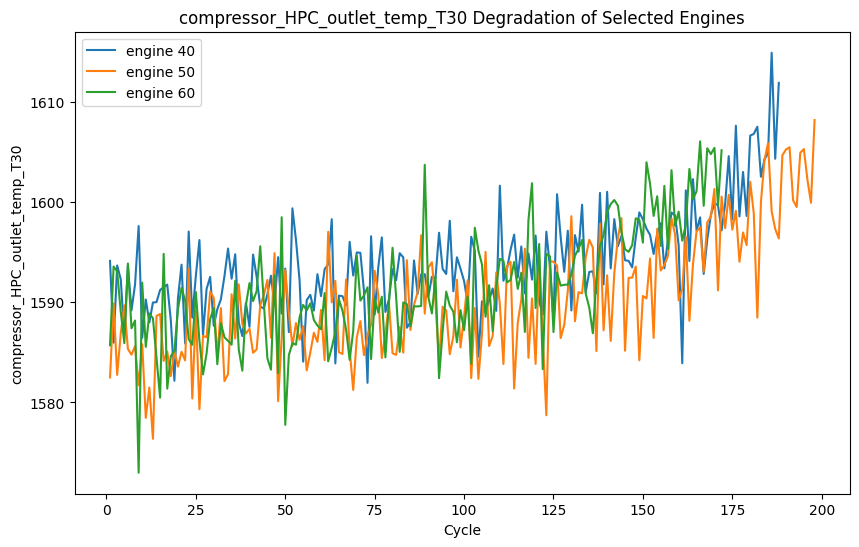

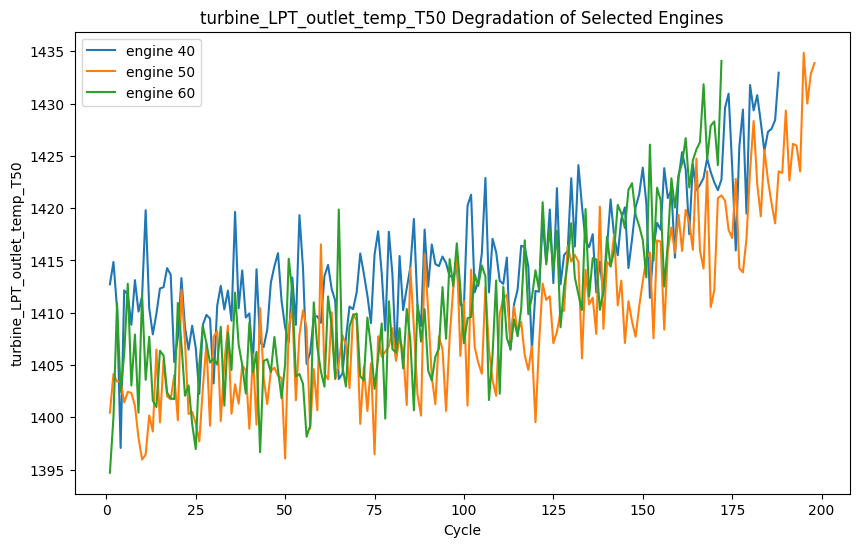

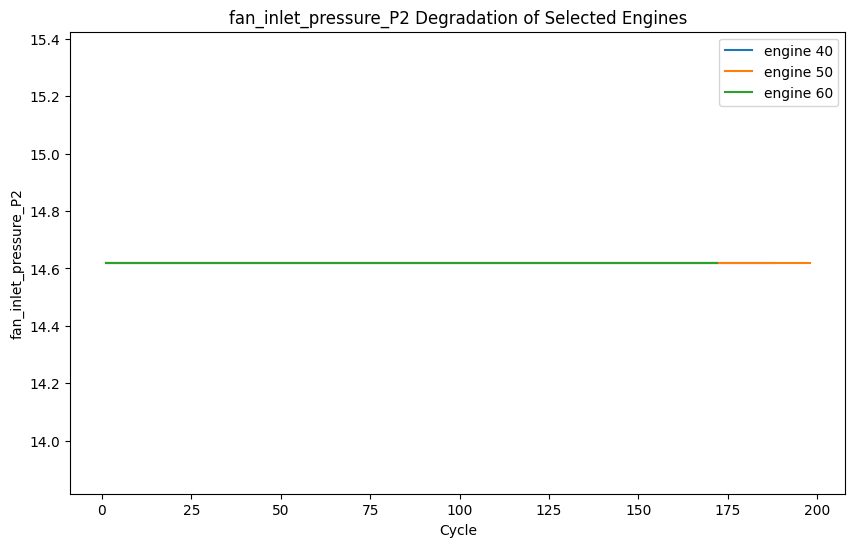

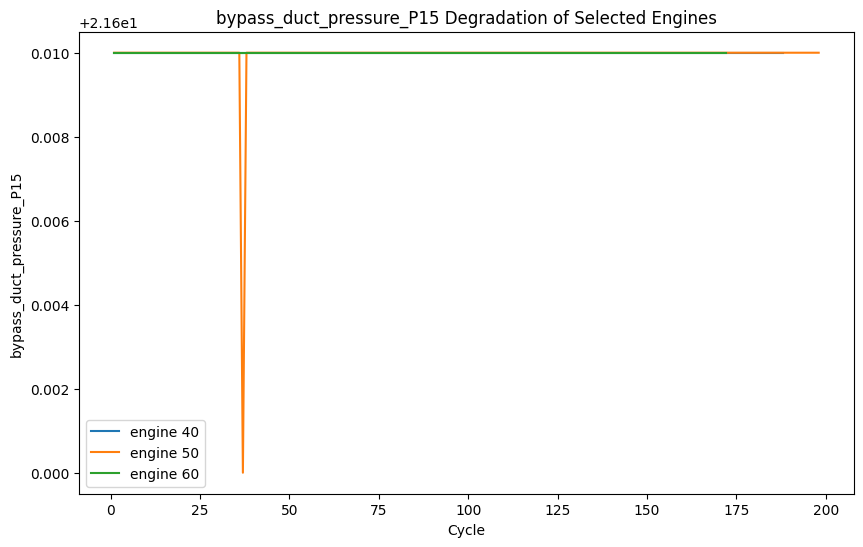

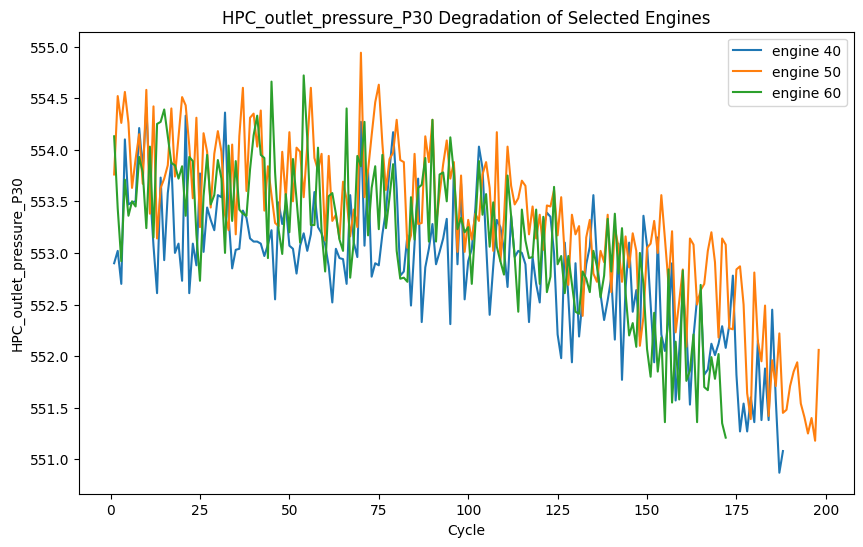

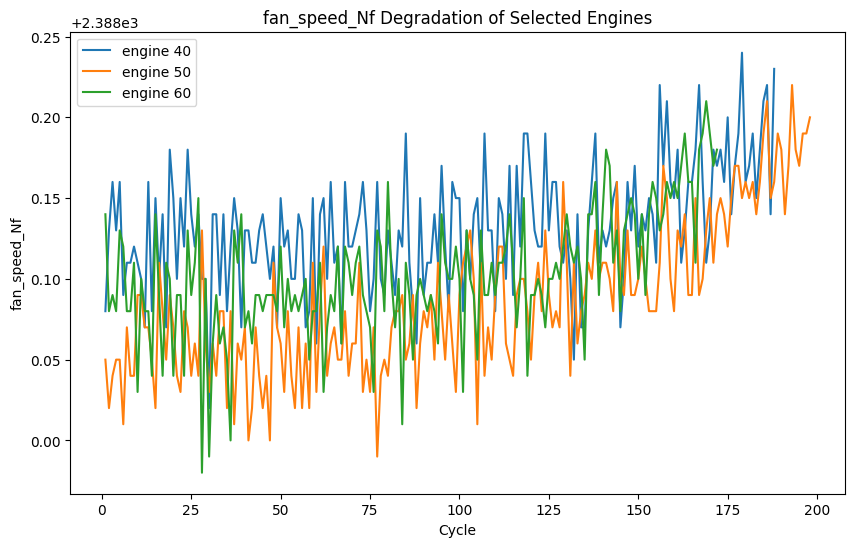

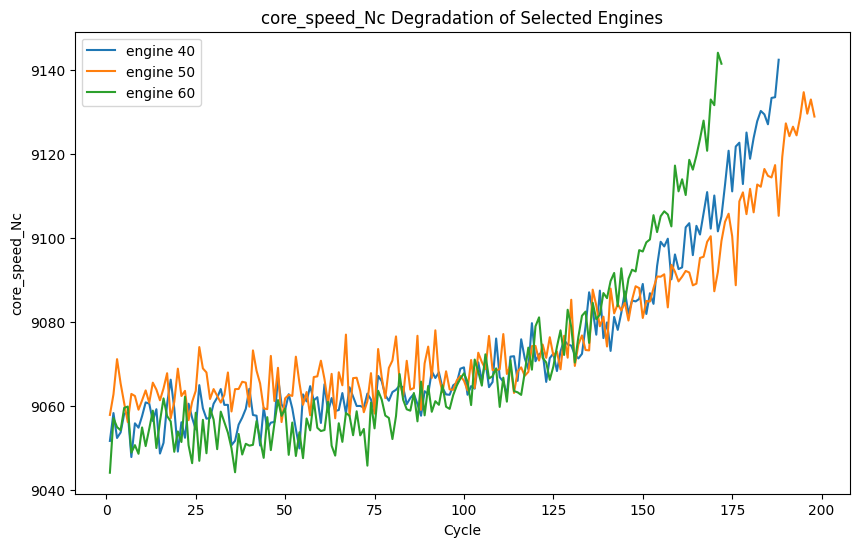

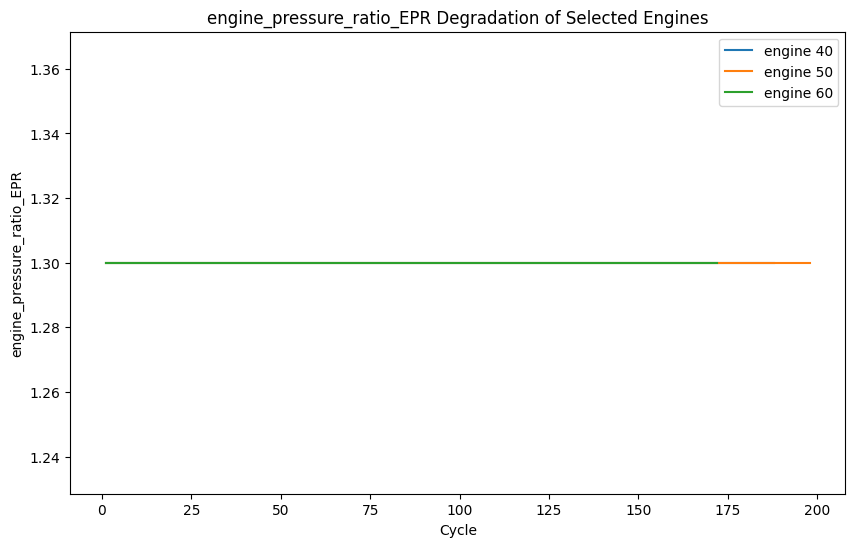

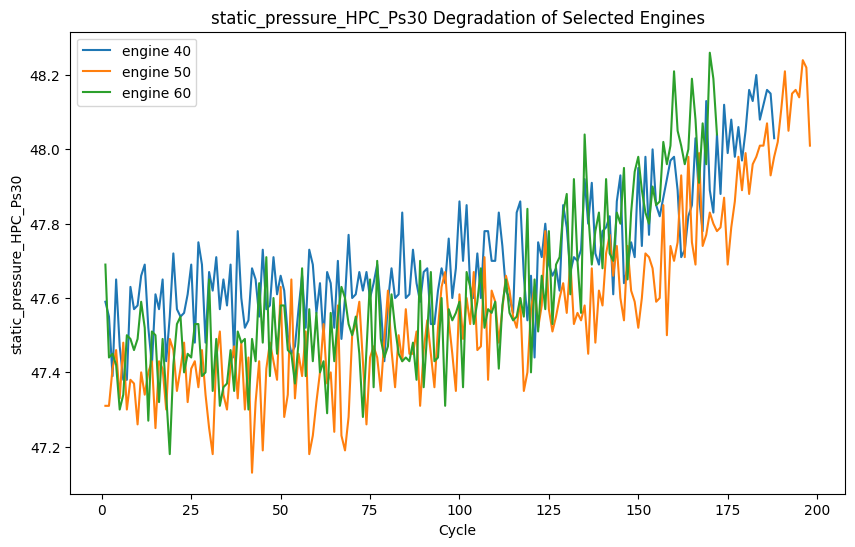

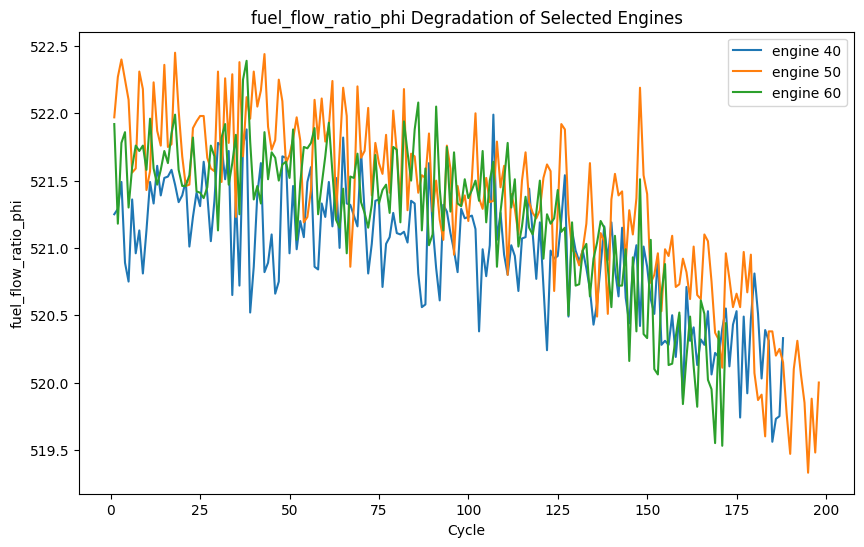

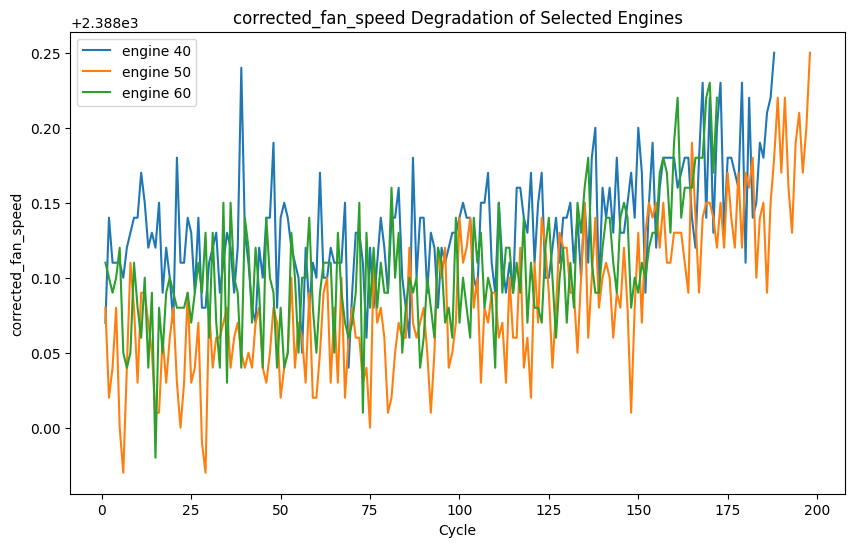

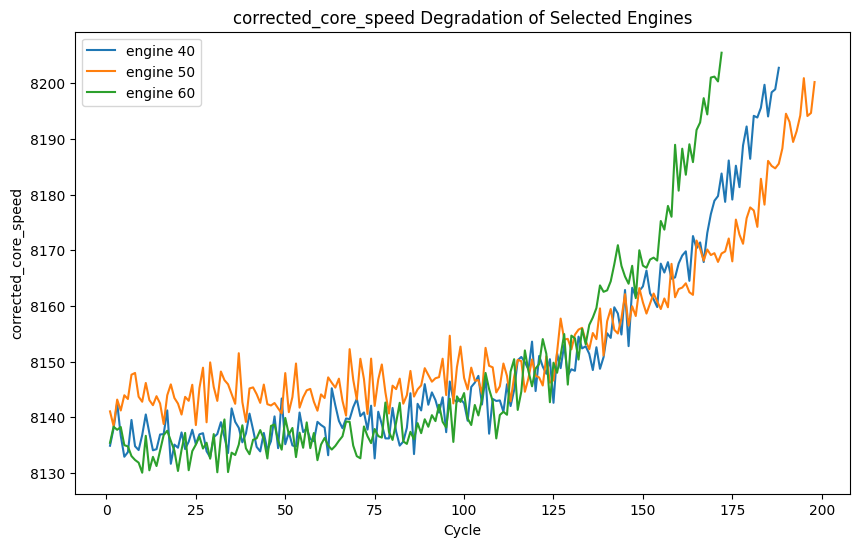

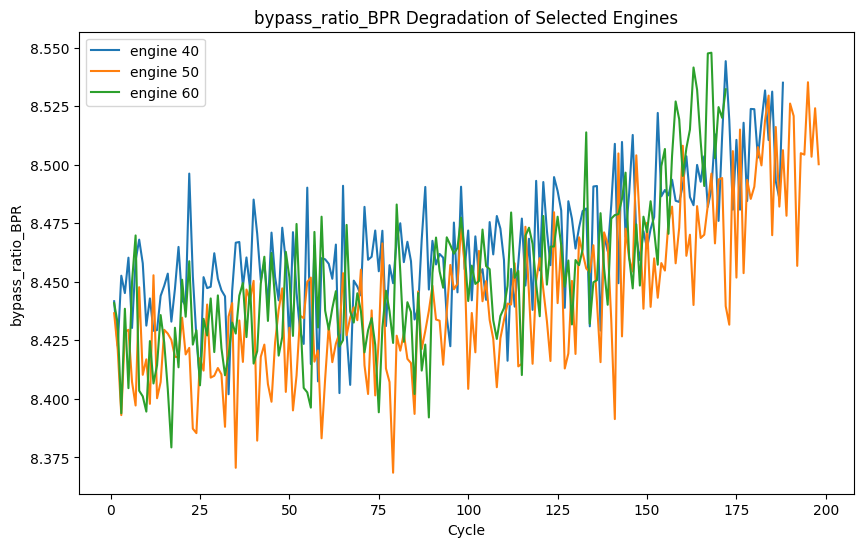

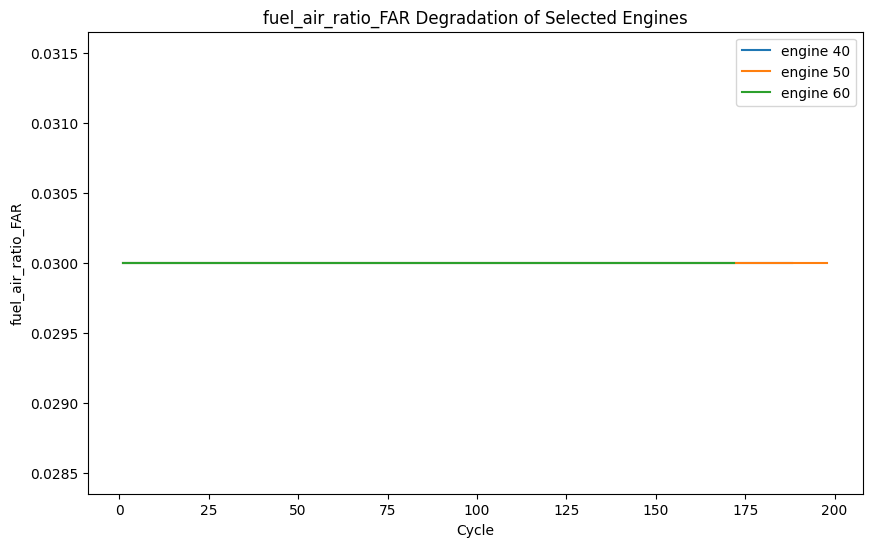

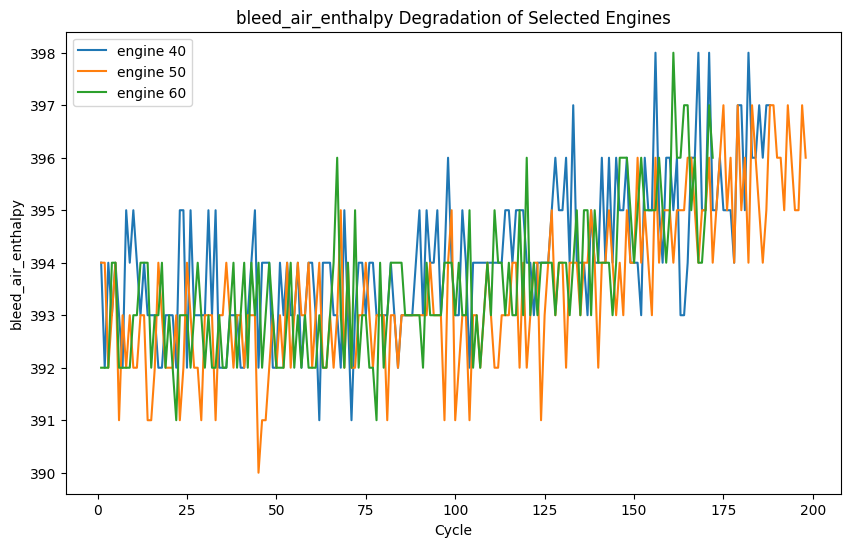

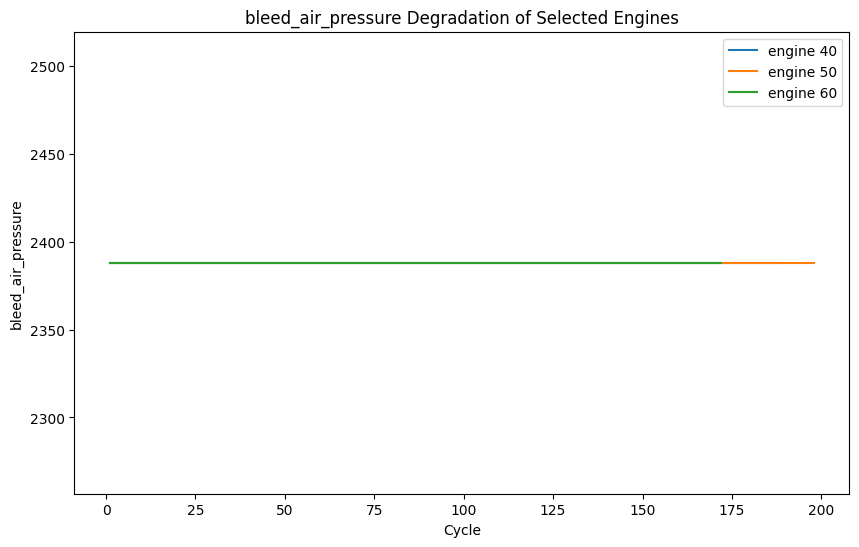

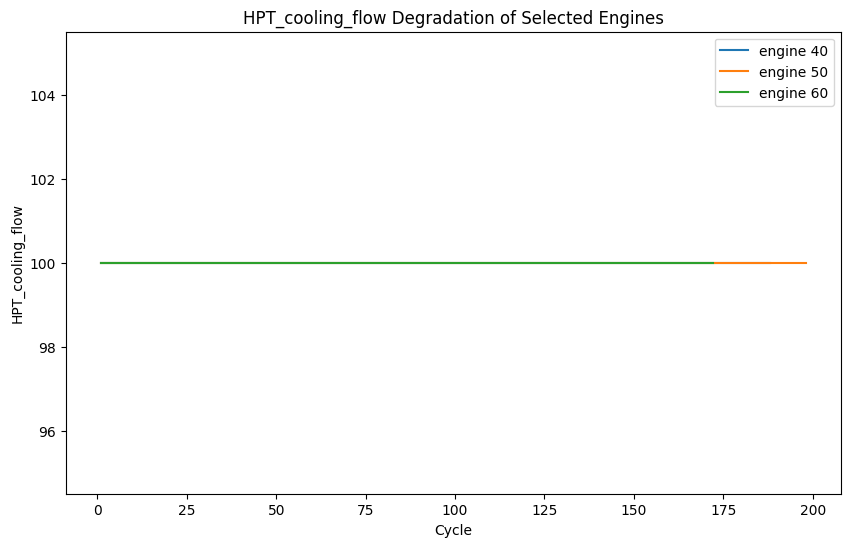

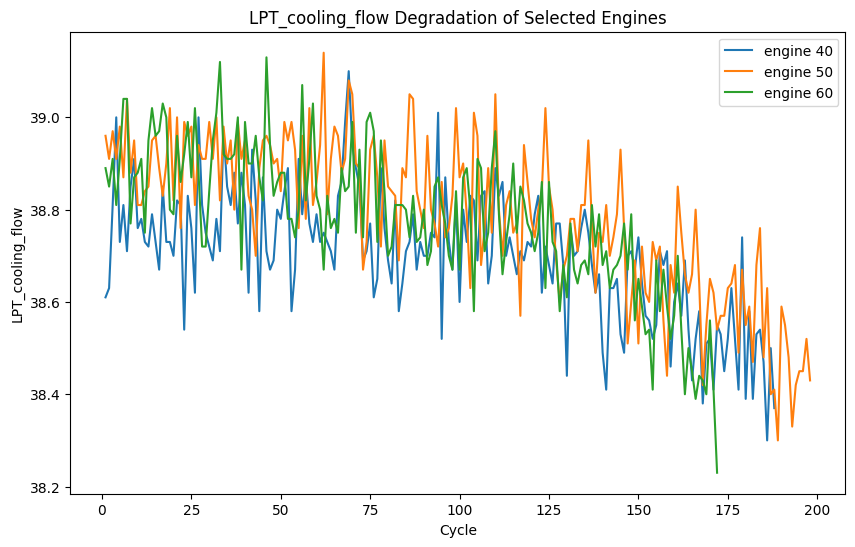

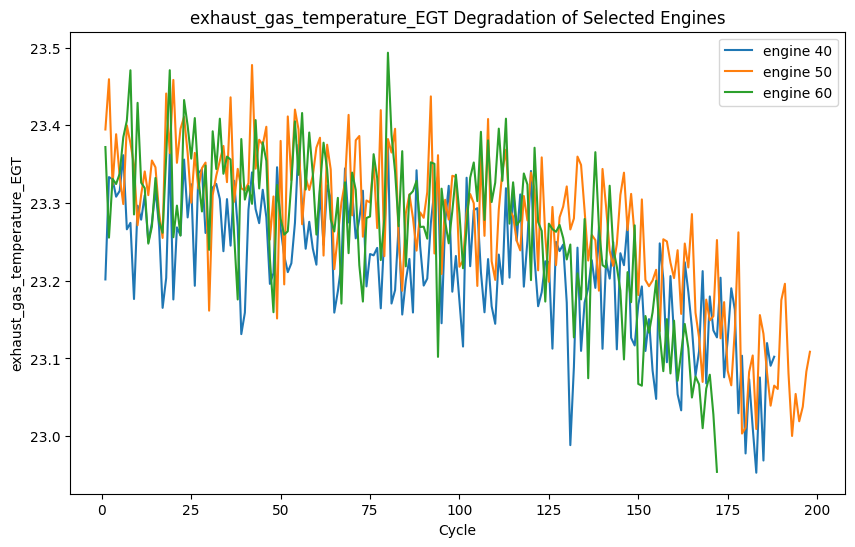

In [16]:
engines = [40, 50, 60]

sensor_cols = [c for c in df.columns 
               if c not in ['engine_id','cycle','RUL',
                            'op_setting_1','op_setting_2','op_setting_3']]

for sensor in sensor_cols:
    
    plt.figure(figsize=(10,6))

    for i in engines:
        temp = df[df['engine_id'] == i]
        plt.plot(temp['cycle'], temp[sensor], label=f'engine {i}')

    plt.legend()
    plt.xlabel("Cycle")
    plt.ylabel(sensor)
    plt.title(f"{sensor} Degradation of Selected Engines")

    plt.show()

### Sự thay đổi của cảm biến theo chu kỳ hoạt động 

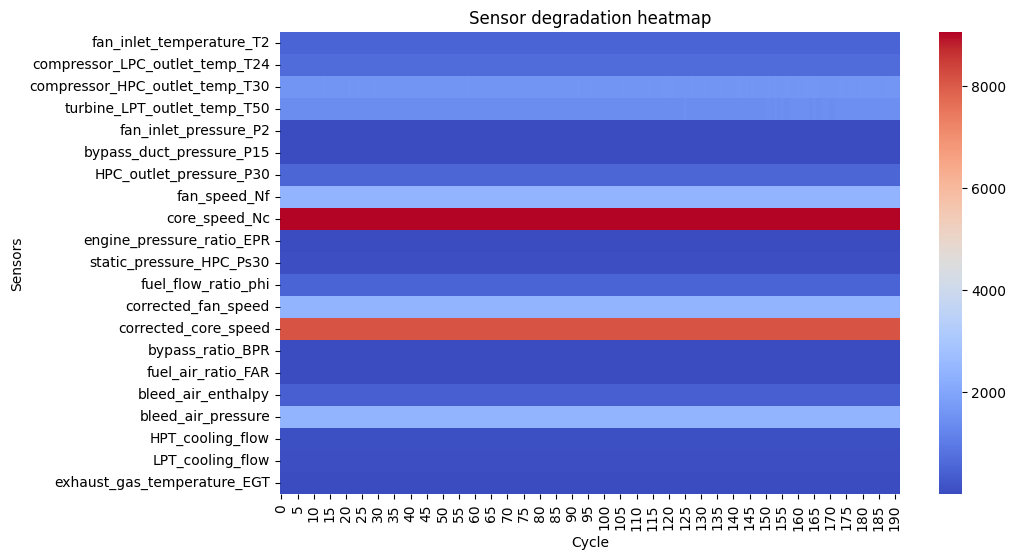

In [17]:


engine1 = df[df['engine_id']==1]

plt.figure(figsize=(10,6))

sns.heatmap(engine1.drop(columns=['engine_id','cycle','RUL','op_setting_1','op_setting_2','op_setting_3']).T,
            cmap='coolwarm')

plt.xlabel("Cycle")
plt.ylabel("Sensors")

plt.title("Sensor degradation heatmap")

plt.show()

### Phân tích xu hướng của sensor 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_29116\4034901733.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['rolling_var'] = temp['core_speed_Nc'].rolling(20).var()


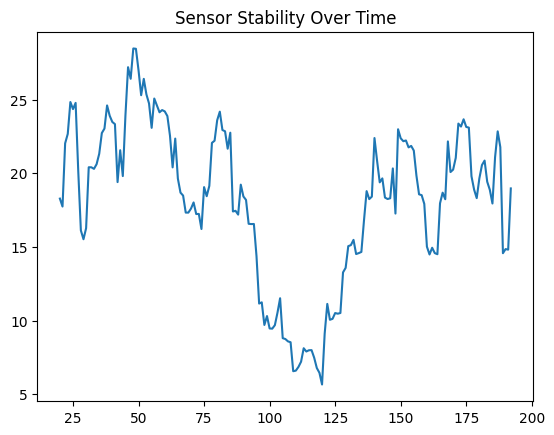

In [18]:
temp = df[df['engine_id']==1]

temp['rolling_var'] = temp['core_speed_Nc'].rolling(20).var()

plt.plot(temp['cycle'], temp['rolling_var'])

plt.title("Sensor Stability Over Time")

plt.show()

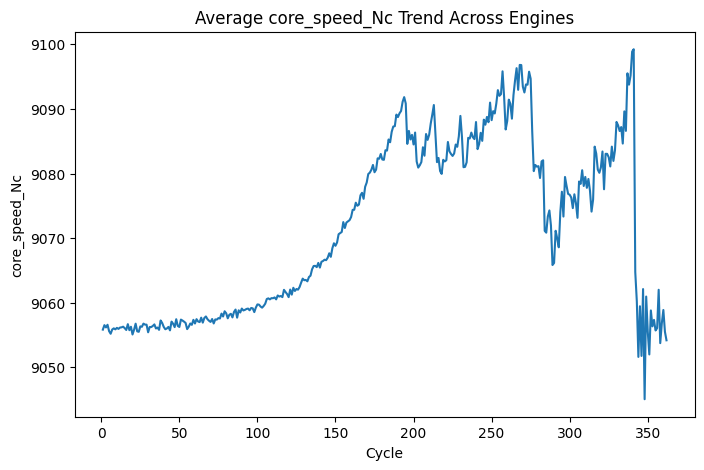

In [19]:
sensor = 'core_speed_Nc'

avg_sensor = df.groupby('cycle')[sensor].mean()

plt.figure(figsize=(8,5))
plt.plot(avg_sensor)

plt.xlabel("Cycle")
plt.ylabel(sensor)
plt.title(f"Average {sensor} Trend Across Engines")

plt.show()

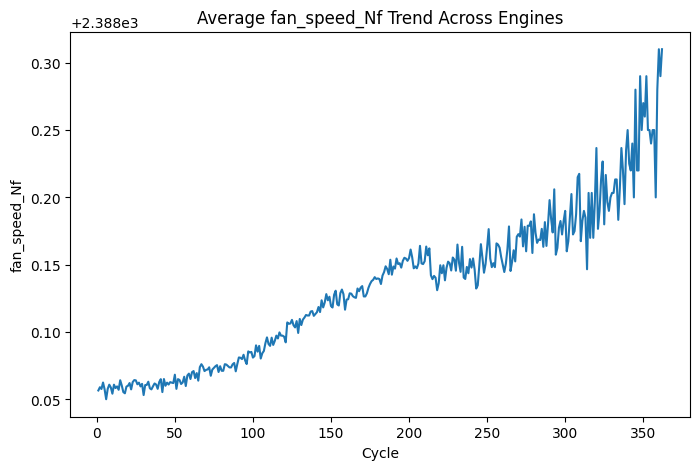

In [20]:
sensor = 'fan_speed_Nf'

avg_sensor = df.groupby('cycle')[sensor].mean()

plt.figure(figsize=(8,5))
plt.plot(avg_sensor)

plt.xlabel("Cycle")
plt.ylabel(sensor)
plt.title(f"Average {sensor} Trend Across Engines")

plt.show()

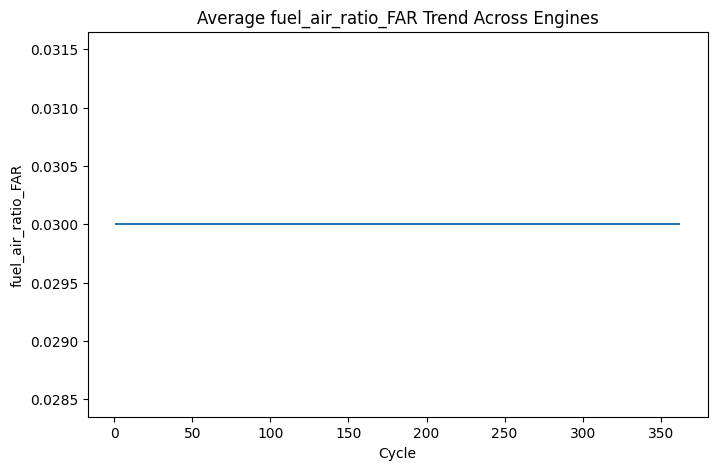

In [21]:
sensor = 'fuel_air_ratio_FAR'

avg_sensor = df.groupby('cycle')[sensor].mean()

plt.figure(figsize=(8,5))
plt.plot(avg_sensor)

plt.xlabel("Cycle")
plt.ylabel(sensor)
plt.title(f"Average {sensor} Trend Across Engines")

plt.show()

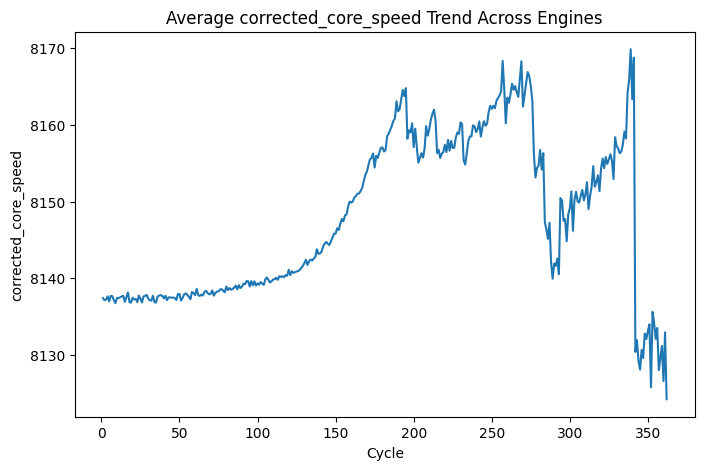

In [22]:
sensor = 'corrected_core_speed'

avg_sensor = df.groupby('cycle')[sensor].mean()

plt.figure(figsize=(8,5))
plt.plot(avg_sensor)

plt.xlabel("Cycle")
plt.ylabel(sensor)
plt.title(f"Average {sensor} Trend Across Engines")

plt.show()

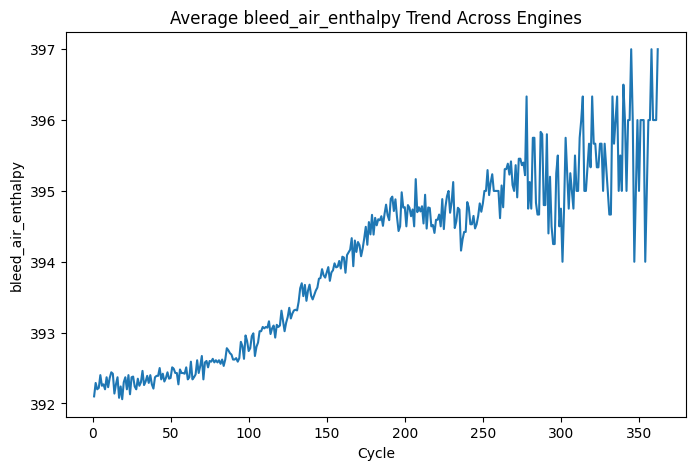

In [23]:
sensor = 'bleed_air_enthalpy'

avg_sensor = df.groupby('cycle')[sensor].mean()

plt.figure(figsize=(8,5))
plt.plot(avg_sensor)

plt.xlabel("Cycle")
plt.ylabel(sensor)
plt.title(f"Average {sensor} Trend Across Engines")

plt.show()

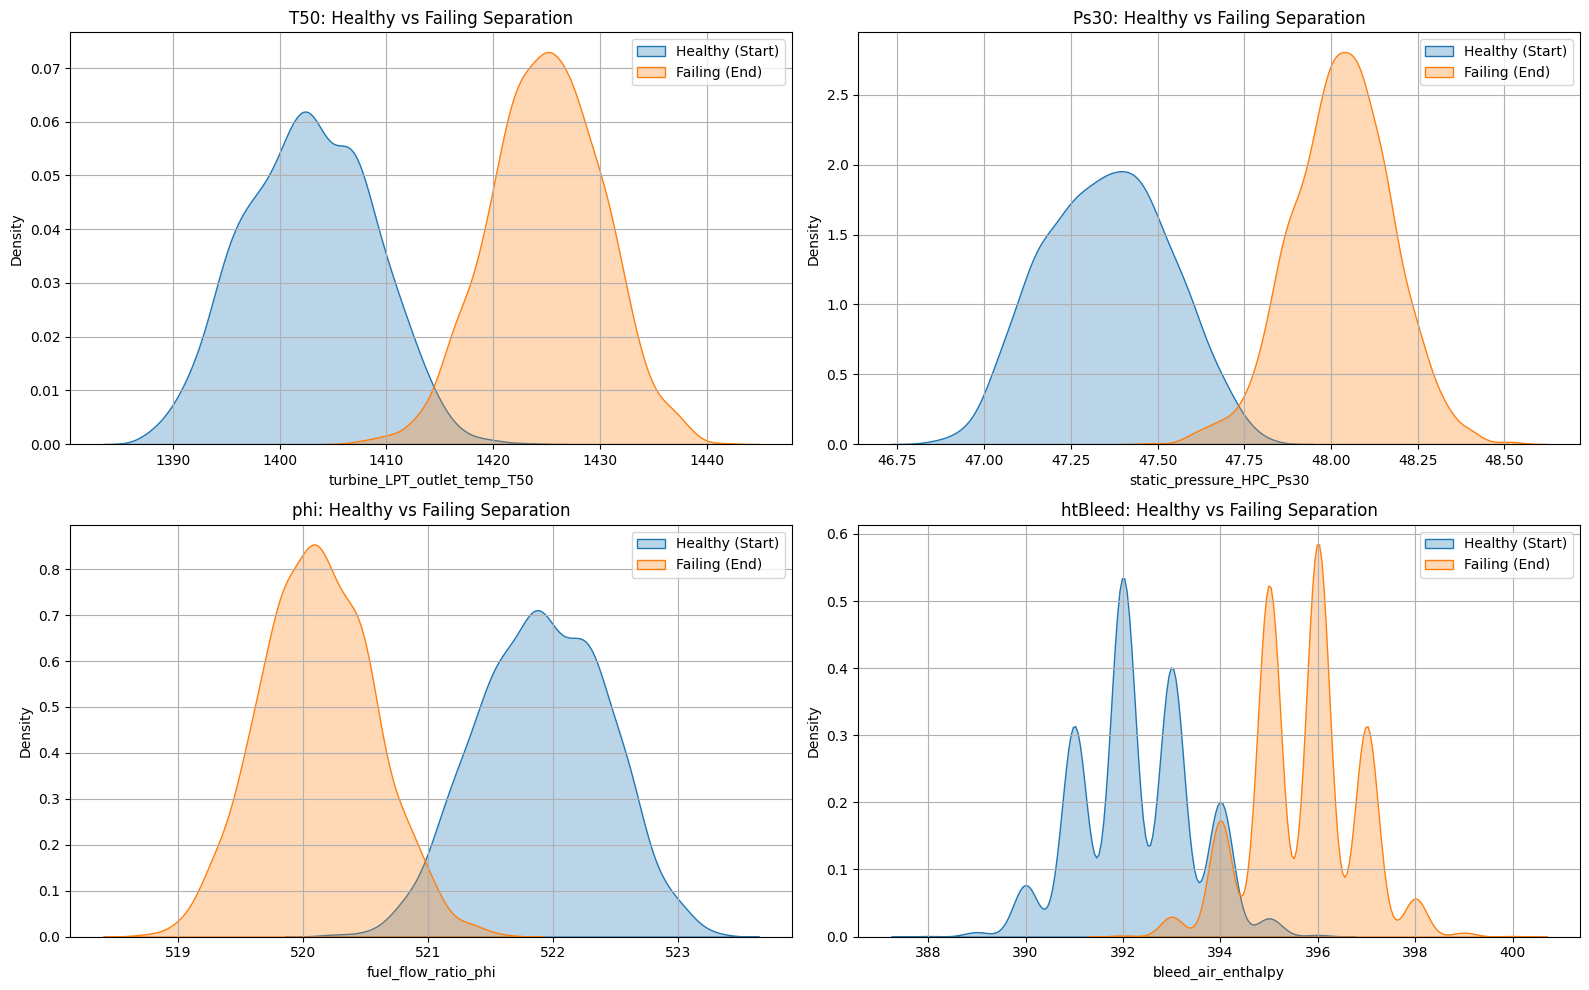

In [24]:

early_life = df[df['cycle'] < 20]
late_life = df[df['RUL'] < 20]

sensors = [
    'turbine_LPT_outlet_temp_T50',
    'static_pressure_HPC_Ps30',
    'fuel_flow_ratio_phi',
    'bleed_air_enthalpy'
]

titles = ['T50', 'Ps30', 'phi', 'htBleed']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, sensor in enumerate(sensors):
    sns.kdeplot(
        early_life[sensor],
        fill=True,
        alpha=0.3,
        label='Healthy (Start)',
        ax=axes[i]
    )
    
    sns.kdeplot(
        late_life[sensor],
        fill=True,
        alpha=0.3,
        label='Failing (End)',
        ax=axes[i]
    )
    
    axes[i].set_title(f'{titles[i]}: Healthy vs Failing Separation')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

## 4.1.3 Feature Engineering

### Xóa các cột không có ảnh hưởng


In [25]:
cols_to_drop = [
    'op_setting_3',
    'fan_inlet_temperature_T2',
    'fan_inlet_pressure_P2',
    'engine_pressure_ratio_EPR',
    'fuel_air_ratio_FAR',
    'bleed_air_pressure',
    'HPT_cooling_flow',
    'bypass_duct_pressure_P15'
    
]

df = df.drop(columns=cols_to_drop)

df.head()

,engine_id,cycle,op_setting_1,op_setting_2,compressor_LPC_outlet_temp_T24,compressor_HPC_outlet_temp_T30,turbine_LPT_outlet_temp_T50,HPC_outlet_pressure_P30,fan_speed_Nf,core_speed_Nc,static_pressure_HPC_Ps30,fuel_flow_ratio_phi,corrected_fan_speed,corrected_core_speed,bypass_ratio_BPR,bleed_air_enthalpy,LPT_cooling_flow,exhaust_gas_temperature_EGT,RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,125
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,125
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,125
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,125


In [26]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   engine_id                       20631 non-null  int64  
 1   cycle                           20631 non-null  int64  
 2   op_setting_1                    20631 non-null  float64
 3   op_setting_2                    20631 non-null  float64
 4   compressor_LPC_outlet_temp_T24  20631 non-null  float64
 5   compressor_HPC_outlet_temp_T30  20631 non-null  float64
 6   turbine_LPT_outlet_temp_T50     20631 non-null  float64
 7   HPC_outlet_pressure_P30         20631 non-null  float64
 8   fan_speed_Nf                    20631 non-null  float64
 9   core_speed_Nc                   20631 non-null  float64
 10  static_pressure_HPC_Ps30        20631 non-null  float64
 11  fuel_flow_ratio_phi             20631 non-null  float64
 12  corrected_fan_speed             

### Xử lý dữ liệu cho huấn luyện


#### Split engine

In [27]:
engines = df['engine_id'].unique()

In [28]:
train_eng = engines[:70]
val_eng   = engines[70:85]
test_eng  = engines[85:]

train_df = df[df['engine_id'].isin(train_eng)].copy()
val_df   = df[df['engine_id'].isin(val_eng)].copy()
test_df  = df[df['engine_id'].isin(test_eng)].copy()

#### Feature + Scaling

In [29]:
features = [c for c in train_df.columns if c not in ['engine_id', 'RUL']]

scaler = MinMaxScaler()

train_df[features] = scaler.fit_transform(train_df[features])
val_df[features]   = scaler.transform(val_df[features])
test_df[features]  = scaler.transform(test_df[features])




#### ML Data

In [30]:
X_train_ml = train_df[features]
y_train_ml = train_df['RUL']

X_val_ml = val_df[features]
y_val_ml = val_df['RUL']

X_test_ml = test_df[features]
y_test_ml = test_df['RUL']

In [31]:
X_train_ml.head()

,cycle,op_setting_1,op_setting_2,compressor_LPC_outlet_temp_T24,compressor_HPC_outlet_temp_T30,turbine_LPT_outlet_temp_T50,HPC_outlet_pressure_P30,fan_speed_Nf,core_speed_Nc,static_pressure_HPC_Ps30,fuel_flow_ratio_phi,corrected_fan_speed,corrected_core_speed,bypass_ratio_BPR,bleed_air_enthalpy,LPT_cooling_flow,exhaust_gas_temperature_EGT
0,0.00000,0.456647,0.166667,0.183735,0.425154,0.257356,0.726248,0.242424,0.109755,0.365269,0.633262,0.205882,0.187533,0.356559,0.363636,0.708661,0.725482
1,0.00277,0.606936,0.250000,0.283133,0.473456,0.303487,0.628019,0.212121,0.100242,0.377246,0.765458,0.279412,0.150183,0.404438,0.363636,0.661417,0.732001
2,0.00554,0.248555,0.750000,0.343373,0.386193,0.322739,0.710145,0.272727,0.140043,0.245509,0.795309,0.220588,0.159298,0.349942,0.181818,0.622047,0.619473
3,0.00831,0.537572,0.500000,0.343373,0.267715,0.280421,0.740741,0.318182,0.124518,0.161677,0.889126,0.294118,0.162441,0.156870,0.363636,0.566929,0.661565
4,0.01108,0.387283,0.333333,0.349398,0.269082,0.359426,0.668277,0.242424,0.149960,0.251497,0.746269,0.235294,0.162284,0.395095,0.454545,0.582677,0.704790


####   Sequence Data (LSTM / CNN)


In [32]:
def create_sequences(df, seq_len=30):
    X, y = [], []
    
    for engine_id in df['engine_id'].unique():
        temp = df[df['engine_id'] == engine_id]
        
        data = temp[features].values
        target = temp['RUL'].values
        
        for i in range(len(temp) - seq_len):
            X.append(data[i:i+seq_len])
            y.append(target[i+seq_len])
    
    return np.array(X), np.array(y)

SEQ_LEN = 30

X_train_seq, y_train_seq = create_sequences(train_df, SEQ_LEN)
X_val_seq, y_val_seq     = create_sequences(val_df, SEQ_LEN)
X_test_seq, y_test_seq   = create_sequences(test_df, SEQ_LEN)


## Huấn luyện mô hình

### Linear Regresstion

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score


modellr = LinearRegression()
modellr.fit(X_train_ml, y_train_ml)  


def evaluate(y_true, y_pred, name):
    print(f"\n=== {name} ===")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", root_mean_squared_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))


y_val_pred = modellr.predict(X_val_ml)
evaluate(y_val_ml, y_val_pred, "Linear Regression (Validation)")


y_test_pred = modellr.predict(X_test_ml)
evaluate(y_test_ml, y_test_pred, "Linear Regression (Test)")


=== Linear Regression (Validation) ===
MAE: 15.141560393658619
RMSE: 18.588498102522674
R2: 0.7996547327733291

=== Linear Regression (Test) ===
MAE: 19.213325553422905
RMSE: 23.525567306130736
R2: 0.677239160428049


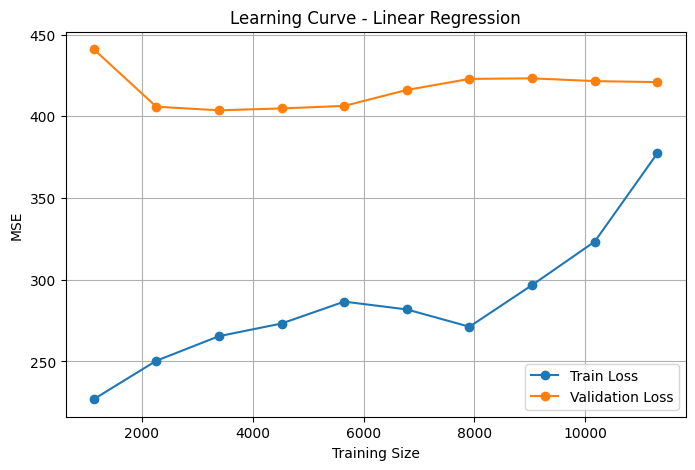

In [34]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(),
    X_train_ml, y_train_ml,
    cv=5,
    scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# đổi về MSE dương
train_scores = -train_scores
val_scores = -val_scores

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label="Train Loss")
plt.plot(train_sizes, val_mean, marker='o', label="Validation Loss")
plt.title("Learning Curve - Linear Regression")
plt.xlabel("Training Size")
plt.ylabel("MSE")
plt.legend()
plt.grid()
plt.show()

### Random Forest

In [35]:

def evaluate_regression(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n=== {name} ===")
    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2  : {r2:.4f}")

In [36]:
from sklearn.ensemble import RandomForestRegressor

best_score = -999
best_rf = None
best_params = None

for n_estimators in [200, 300, 500]:
    for max_depth in [10, 15, 20, None]:
        for min_samples_leaf in [1, 2, 4]:
            
            rf = RandomForestRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                max_features='sqrt',
                n_jobs=-1,
                random_state=42
            )
            
            rf.fit(X_train_ml, y_train_ml)
            y_val_pred = rf.predict(X_val_ml)
            score = r2_score(y_val_ml, y_val_pred)
            
            if score > best_score:
                best_score = score
                best_rf = rf
                best_params = {
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf
                }

print("Best RF params:", best_params)
print("Best validation R2:", round(best_score, 4))

Best RF params: {'n_estimators': 500, 'max_depth': 10, 'min_samples_leaf': 4}
Best validation R2: 0.8402


In [37]:
y_val_pred = best_rf.predict(X_val_ml)
evaluate_regression(y_val_ml, y_val_pred, "Random Forest - Validation")

y_test_pred = best_rf.predict(X_test_ml)
evaluate_regression(y_test_ml, y_test_pred, "Random Forest - Test")


=== Random Forest - Validation ===
MAE : 11.7038
RMSE: 16.6020
R2  : 0.8402

=== Random Forest - Test ===
MAE : 13.8604
RMSE: 18.6017
R2  : 0.7982


                           feature  importance
0                            cycle    0.269784
9         static_pressure_HPC_Ps30    0.152159
5      turbine_LPT_outlet_temp_T50    0.123701
10             fuel_flow_ratio_phi    0.107765
6          HPC_outlet_pressure_P30    0.070712
13                bypass_ratio_BPR    0.056320
8                    core_speed_Nc    0.047851
16     exhaust_gas_temperature_EGT    0.040722
12            corrected_core_speed    0.036961
15                LPT_cooling_flow    0.027971
3   compressor_LPC_outlet_temp_T24    0.019400
14              bleed_air_enthalpy    0.014948
4   compressor_HPC_outlet_temp_T30    0.010456
7                     fan_speed_Nf    0.010234
11             corrected_fan_speed    0.007706
1                     op_setting_1    0.002107
2                     op_setting_2    0.001202


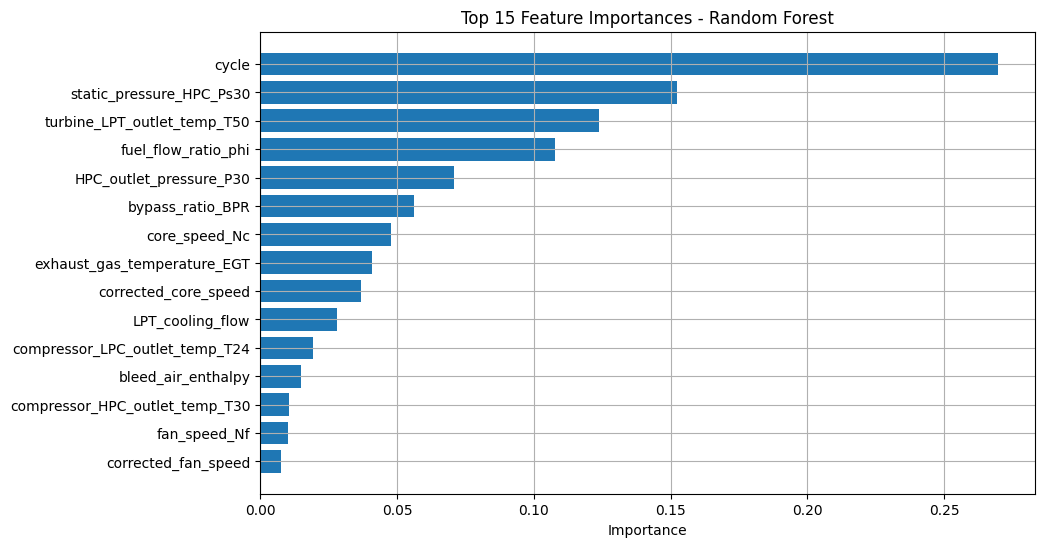

In [38]:
importance_df = (
    pd.DataFrame({
        'feature': features,
        'importance': best_rf.feature_importances_
    })
    .sort_values('importance', ascending=False)
)

print(importance_df.head(20))

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'].head(15)[::-1],
         importance_df['importance'].head(15)[::-1])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances - Random Forest")
plt.grid(True)
plt.show()

### XG Boost

In [39]:
from xgboost import XGBRegressor

best_score = -999
best_model = None
best_params = None

param_grid = {
    "max_depth": [4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

for depth in param_grid["max_depth"]:
    for lr in param_grid["learning_rate"]:
        for subsample in param_grid["subsample"]:
            for colsample in param_grid["colsample_bytree"]:

                modelxgb = XGBRegressor(
                    n_estimators=100,
                    max_depth=depth,
                    learning_rate=lr,
                    subsample=subsample,
                    colsample_bytree=colsample,
                    objective='reg:squarederror',
                    eval_metric='rmse',
                    random_state=42,
                    early_stopping_rounds=50
                )

                modelxgb.fit(
                    X_train_ml, y_train_ml,
                    eval_set=[(X_val_ml, y_val_ml)],
                    verbose=False
                )

                y_val_pred = modelxgb.predict(X_val_ml)
                score = r2_score(y_val_ml, y_val_pred)

                if score > best_score:
                    best_score = score
                    best_model = modelxgb
                    best_params = {
                        "max_depth": depth,
                        "learning_rate": lr,
                        "subsample": subsample,
                        "colsample_bytree": colsample
                    }

print("Best params:", best_params)
print("Best validation R2:", round(best_score, 4))



Best params: {'max_depth': 4, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8}
Best validation R2: 0.8319


In [40]:

y_val_pred = best_model.predict(X_val_ml)
evaluate_regression(y_val_ml, y_val_pred, "Best XGBoost - Validation")

# Test
y_test_pred = best_model.predict(X_test_ml)
evaluate_regression(y_test_ml, y_test_pred, "Best XGBoost - Test")


=== Best XGBoost - Validation ===
MAE : 12.5989
RMSE: 17.0254
R2  : 0.8319

=== Best XGBoost - Test ===
MAE : 14.6378
RMSE: 19.1472
R2  : 0.7862


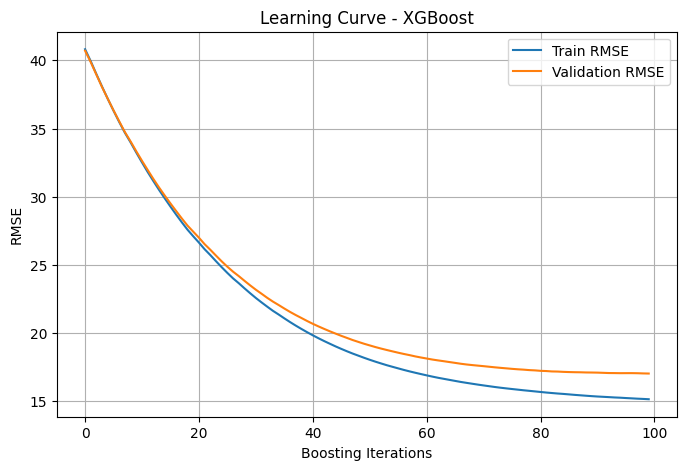

In [41]:
xgb_curve_model = XGBRegressor(
    n_estimators=100,
    max_depth=best_params["max_depth"],
    learning_rate=best_params["learning_rate"],
    subsample=best_params["subsample"],
    colsample_bytree=best_params["colsample_bytree"],
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42,
      early_stopping_rounds=50
)

xgb_curve_model.fit(
    X_train_ml, y_train_ml,
    eval_set=[(X_train_ml, y_train_ml), (X_val_ml, y_val_ml)],
    verbose=False
)

curve_results = xgb_curve_model.evals_result()
train_rmse = curve_results['validation_0']['rmse']
val_rmse   = curve_results['validation_1']['rmse']

plt.figure(figsize=(8, 5))
plt.plot(train_rmse, label='Train RMSE')
plt.plot(val_rmse, label='Validation RMSE')
plt.title("Learning Curve - XGBoost")
plt.xlabel("Boosting Iterations")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

### GRU

c:\Users\ASUS\anaconda3\envs\turbofan\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 72.2547 - mae: 72.7526 - val_loss: 68.1990 - val_mae: 68.6973 - learning_rate: 3.0000e-04
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 58.3274 - mae: 58.8253 - val_loss: 53.8207 - val_mae: 54.3193 - learning_rate: 3.0000e-04
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 46.1088 - mae: 46.6067 - val_loss: 43.2242 - val_mae: 43.7228 - learning_rate: 3.0000e-04
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 39.3037 - mae: 39.8017 - val_loss: 38.2545 - val_mae: 38.7521 - learning_rate: 3.0000e-04
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 37.1205 - mae: 37.6186 - val_loss: 36.8735 - val_mae: 37.3721 - learning_rate: 3.0000e-04
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 36.8149 - mae: 37.3130 - val_loss: 36.6075 - val_mae: 37.1054 - learning_rate: 3.0000e-04
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 34.6636 - mae: 35.1610 - val_loss

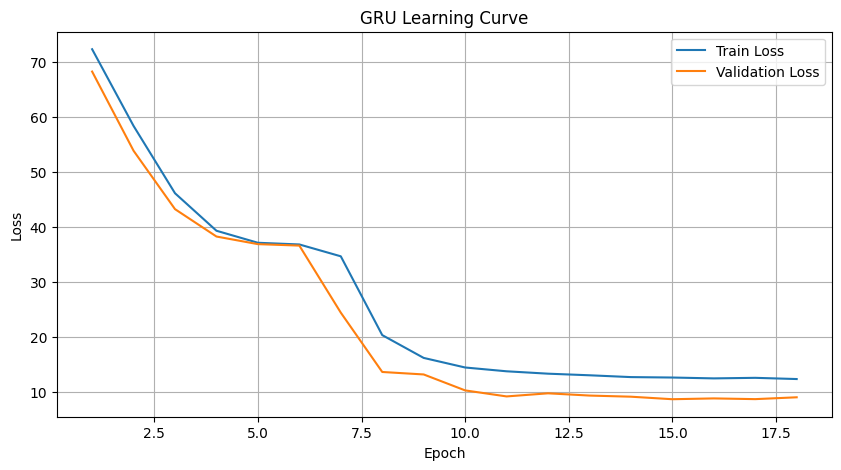

In [42]:
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import matplotlib.pyplot as plt

# ===== MODEL =====
modelgru = tf.keras.models.Sequential([
    tf.keras.layers.GRU(64, return_sequences=True, input_shape=(SEQ_LEN, X_train_seq.shape[2])),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.GRU(32),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

modelgru.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='huber',
    metrics=['mae']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

# ===== TRAIN =====
history = modelgru.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=64,
    shuffle=True,
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

# ===== EVALUATE FUNCTION =====
def evaluate(y_true, y_pred, name):
    print(f"\n=== {name} ===")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", root_mean_squared_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))

# ===== VALIDATION =====
y_val_pred = modelgru.predict(X_val_seq).flatten()
evaluate(y_val_seq, y_val_pred, "GRU (Validation)")

# ===== TEST =====
y_test_pred = modelgru.predict(X_test_seq).flatten()
evaluate(y_test_seq, y_test_pred, "GRU (Test)")

# ===== PLOT LOSS =====
train_loss = history.history['loss']
val_loss   = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(10,5))
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GRU Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

### LSTM



Epoch 1/50


c:\Users\ASUS\anaconda3\envs\turbofan\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 72.5155 - mae: 73.0136 - val_loss: 68.8067 - val_mae: 69.3042 - learning_rate: 3.0000e-04
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 59.9407 - mae: 60.4389 - val_loss: 56.6005 - val_mae: 57.0988 - learning_rate: 3.0000e-04
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - loss: 49.1807 - mae: 49.6788 - val_loss: 46.6975 - val_mae: 47.1961 - learning_rate: 3.0000e-04
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - loss: 41.8621 - mae: 42.3606 - val_loss: 40.5763 - val_mae: 41.0742 - learning_rate: 3.0000e-04
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 38.2043 - mae: 38.7024 - val_loss: 37.8355 - val_mae: 38.3335 - learning_rate: 3.0000e-04
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 37.0984 - mae: 37.5965 - val_loss: 36.9008 - val_mae: 37.3989 - learning_rate: 3.0000e-04
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 36.8649 - mae: 37.3629 - val_loss: 36.5960 -

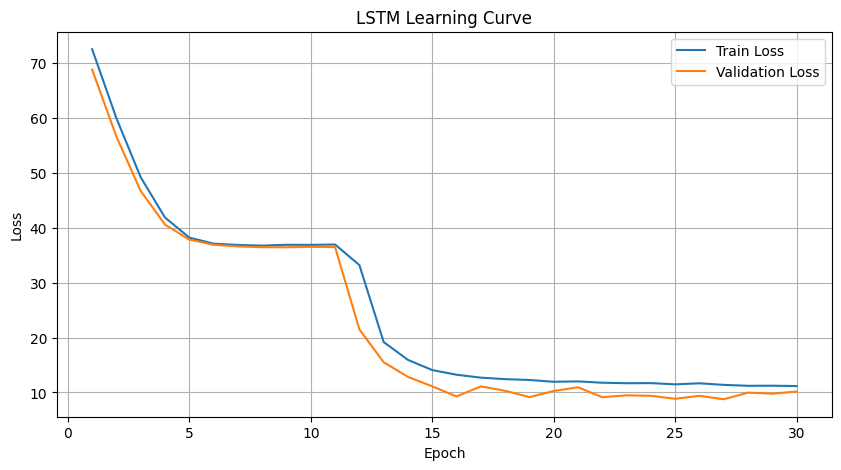

In [43]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# ===== MODEL =====
modellstm = tf.keras.models.Sequential([
    
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, X_train_seq.shape[2])),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

modellstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='huber',
    metrics=['mae']
)

# ===== CALLBACKS =====
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# ===== TRAIN =====
history = modellstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=64,
    shuffle=True,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ===== EVALUATE FUNCTION =====
def evaluate(y_true, y_pred, name):
    print(f"\n=== {name} ===")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", root_mean_squared_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))

# ===== VALIDATION =====
y_val_pred = modellstm.predict(X_val_seq).flatten()
evaluate(y_val_seq, y_val_pred, "LSTM (Validation)")

# ===== TEST =====
y_test_pred = modellstm.predict(X_test_seq).flatten()
evaluate(y_test_seq, y_test_pred, "LSTM (Test)")

# ===== PLOT =====
train_loss = history.history['loss']
val_loss   = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(10,5))
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

## Visualization kết quả 

In [44]:
import pandas as pd
import numpy as np


test_official = pd.read_csv( "../data_csv/test_FD001.csv")   
rul_official  =pd.read_csv( "../data_csv/RUL_FD001.csv"  ) 



test_official = test_official.dropna(axis=1, how='all')

original_columns = (
    ['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] +
    [f'sensor_{i}' for i in range(1, 22)]
)

test_official.columns = original_columns
rul_official.columns = ['true_RUL']

sensor_map = {
    "sensor_1":  "fan_inlet_temperature_T2",
    "sensor_2":  "compressor_LPC_outlet_temp_T24",
    "sensor_3":  "compressor_HPC_outlet_temp_T30",
    "sensor_4":  "turbine_LPT_outlet_temp_T50",
    "sensor_5":  "fan_inlet_pressure_P2",
    "sensor_6":  "bypass_duct_pressure_P15",
    "sensor_7":  "HPC_outlet_pressure_P30",
    "sensor_8":  "fan_speed_Nf",
    "sensor_9":  "core_speed_Nc",
    "sensor_10": "engine_pressure_ratio_EPR",
    "sensor_11": "static_pressure_HPC_Ps30",
    "sensor_12": "fuel_flow_ratio_phi",
    "sensor_13": "corrected_fan_speed",
    "sensor_14": "corrected_core_speed",
    "sensor_15": "bypass_ratio_BPR",
    "sensor_16": "fuel_air_ratio_FAR",
    "sensor_17": "bleed_air_enthalpy",
    "sensor_18": "bleed_air_pressure",
    "sensor_19": "HPT_cooling_flow",
    "sensor_20": "LPT_cooling_flow",
    "sensor_21": "exhaust_gas_temperature_EGT"
}

test_official = test_official.rename(columns=sensor_map)

# =========================
# 4. NẾU TRAIN CỦA BẠN CÓ DROP CỘT THÌ DROP GIỐNG HỆT
# =========================
cols_to_drop = [
    'op_setting_3',
    'fan_inlet_temperature_T2',
    'fan_inlet_pressure_P2',
    'engine_pressure_ratio_EPR',
    'fuel_air_ratio_FAR',
    'bleed_air_pressure',
    'HPT_cooling_flow',
    'bypass_duct_pressure_P15'
]

cols_to_drop = [c for c in cols_to_drop if c in test_official.columns]
test_official = test_official.drop(columns=cols_to_drop)



# =========================
# 6. GIỮ ĐÚNG THỨ TỰ FEATURE GIỐNG TRAIN
# =========================
missing_features = [f for f in features if f not in test_official.columns]
if missing_features:
    print("Thiếu feature trong test_official:", missing_features)
else:
    print("✅ Test official đã đủ feature.")

# =========================
# 7. SCALE GIỐNG TRAIN
# =========================
test_official[features] = scaler.transform(test_official[features])

print(test_official.head())
print(test_official.shape)
print(rul_official.head())
print(rul_official.shape)

✅ Test official đã đủ feature.
   engine_id    cycle  op_setting_1  op_setting_2  \
0          1  0.00000      0.630058      0.750000   
1          1  0.00277      0.341040      0.250000   
2          1  0.00554      0.514451      0.583333   
3          1  0.00831      0.739884      0.500000   
4          1  0.01108      0.578035      0.500000   

   compressor_LPC_outlet_temp_T24  compressor_HPC_outlet_temp_T30  \
0                        0.545181                        0.324675   
1                        0.150602                        0.396674   
2                        0.376506                        0.362269   
3                        0.370482                        0.298018   
4                        0.391566                        0.367965   

   turbine_LPT_outlet_temp_T50  HPC_outlet_pressure_P30  fan_speed_Nf  \
0                     0.213948                 0.652174      0.212121   
1                     0.163276                 0.805153      0.166667   
2               

In [45]:
# =========================
# 8. ML: LẤY DÒNG CUỐI MỖI ENGINE
# =========================
test_last = test_official.groupby('engine_id').tail(1).copy()

X_test_ml_official = test_last[features]
y_test_ml_official = rul_official['true_RUL'].values

print("X_test_ml_official:", X_test_ml_official.shape)
print("y_test_ml_official:", y_test_ml_official.shape)

X_test_ml_official: (100, 17)
y_test_ml_official: (100,)


In [46]:
# =========================
# 9. DEEP: LẤY SEQUENCE CUỐI MỖI ENGINE
# =========================
def create_last_sequences(df, seq_len, features):
    X = []
    engine_ids = []

    for engine_id in sorted(df['engine_id'].unique()):
        temp = df[df['engine_id'] == engine_id].copy()
        data = temp[features].values

        # nếu chuỗi ngắn hơn seq_len thì pad đầu
        if len(data) < seq_len:
            pad_len = seq_len - len(data)
            pad_block = np.repeat(data[:1], pad_len, axis=0)
            data = np.vstack([pad_block, data])

        last_seq = data[-seq_len:]
        X.append(last_seq)
        engine_ids.append(engine_id)

    return np.array(X), np.array(engine_ids)

X_test_seq_official, engine_ids_test = create_last_sequences(
    test_official, SEQ_LEN, features
)

y_test_seq_official = rul_official['true_RUL'].values

print("X_test_seq_official:", X_test_seq_official.shape)
print("y_test_seq_official:", y_test_seq_official.shape)

X_test_seq_official: (100, 30, 17)
y_test_seq_official: (100,)


In [47]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import pandas as pd

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n=== {name} ===")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)
    return mae, rmse, r2

results = []

# ===== ML =====
y_pred_lr  = modellr.predict(X_test_ml_official)
mae, rmse, r2 = evaluate(y_test_ml_official, y_pred_lr, "Linear Regression - Official Test")
results.append(["Linear Regression", mae, rmse, r2])

y_pred_rf  = best_rf.predict(X_test_ml_official)
mae, rmse, r2 = evaluate(y_test_ml_official, y_pred_rf, "Random Forest - Official Test")
results.append(["Random Forest", mae, rmse, r2])

y_pred_xgb = best_model.predict(X_test_ml_official)
mae, rmse, r2 = evaluate(y_test_ml_official, y_pred_xgb, "XGBoost - Official Test")
results.append(["XGBoost", mae, rmse, r2])

# ===== DEEP =====
y_pred_gru = modelgru.predict(X_test_seq_official).flatten()
mae, rmse, r2 = evaluate(y_test_seq_official, y_pred_gru, "GRU - Official Test")
results.append(["GRU", mae, rmse, r2])

y_pred_lstm = modellstm.predict(X_test_seq_official).flatten()
mae, rmse, r2 = evaluate(y_test_seq_official, y_pred_lstm, "LSTM - Official Test")
results.append(["LSTM", mae, rmse, r2])

# ===== TABLE =====
df_results_official = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
df_results_official = df_results_official.sort_values("R2", ascending=False).reset_index(drop=True)

print("\n===== OFFICIAL TEST RESULTS =====")
print(df_results_official)


=== Linear Regression - Official Test ===
MAE : 17.956075512901265
RMSE: 22.837236986789787
R2  : 0.6979856538149727

=== Random Forest - Official Test ===
MAE : 13.73446520607106
RMSE: 18.43680457923822
R2  : 0.8031607232572631

=== XGBoost - Official Test ===
MAE : 14.366771697998047
RMSE: 18.854286193847656
R2  : 0.7941453456878662
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

=== GRU - Official Test ===
MAE : 10.599254608154297
RMSE: 14.508930206298828
R2  : 0.8780978918075562
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

=== LSTM - Official Test ===
MAE : 11.083199501037598
RMSE: 15.168781280517578
R2  : 0.8667578101158142

===== OFFICIAL TEST RESULTS =====
               Model        MAE       RMSE        R2
0                GRU  10.599255  14.508930  0.878098
1               LSTM  11.083200  15.168781  0.866758
2      Random Forest  13.734465  18.436805  0.803161
3            XGBoost  14.366772  18.854286  0.794145
4  Linear Regression  17.956076  22.837237  0.697986


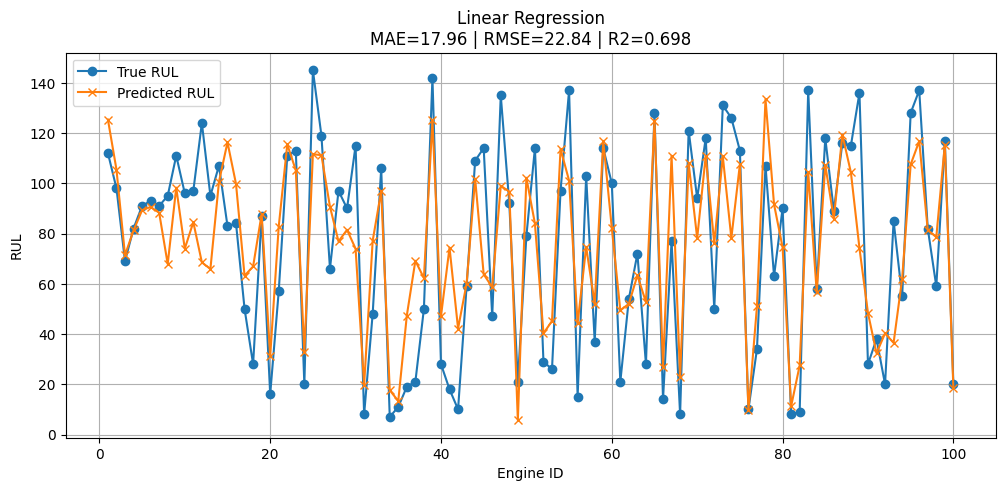

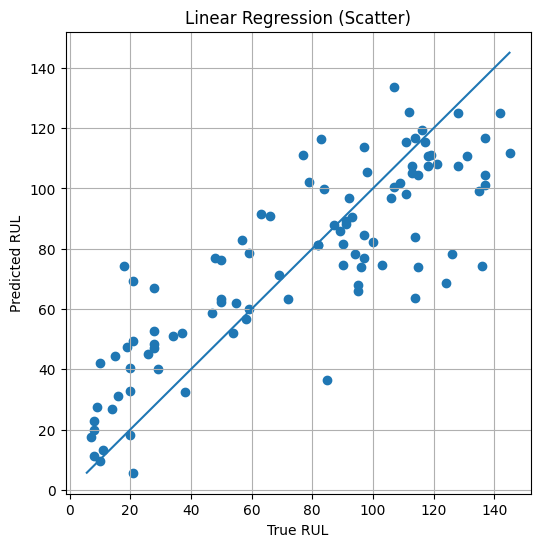

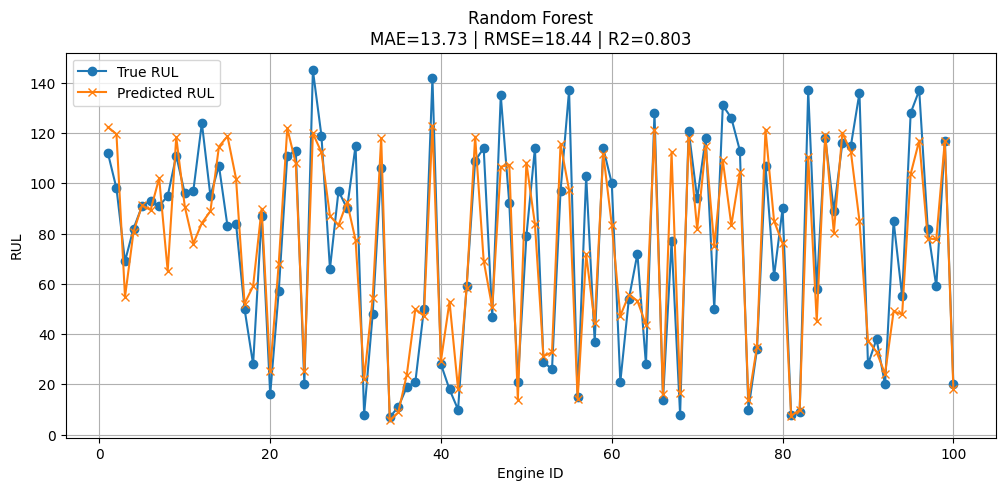

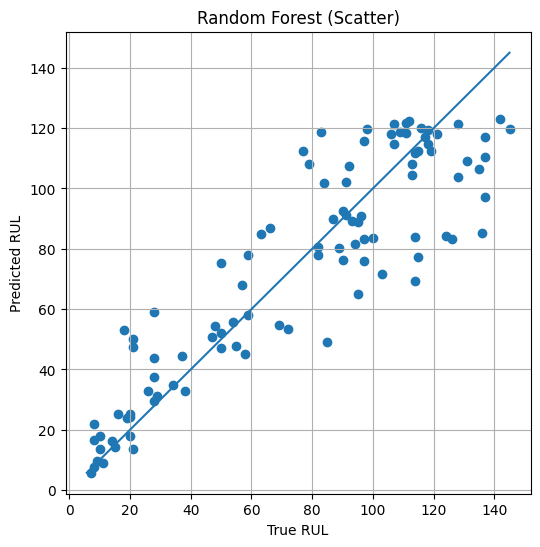

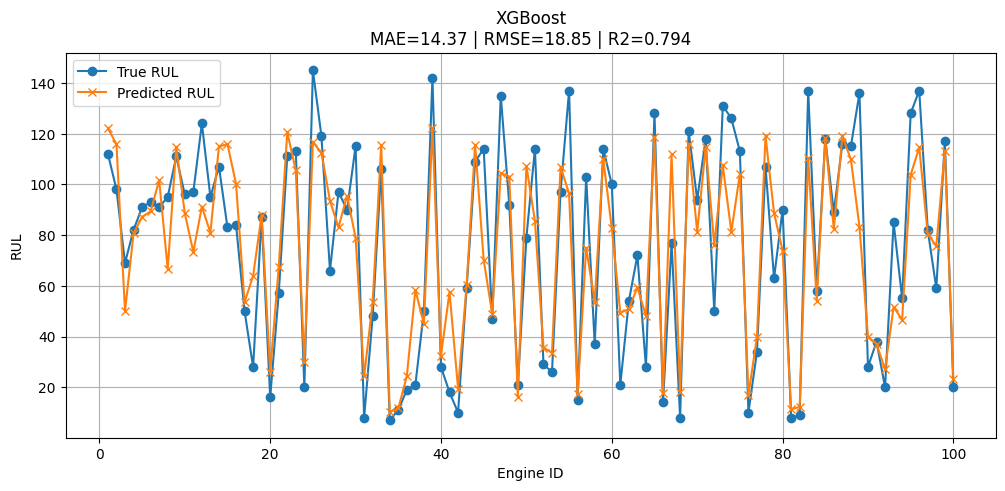

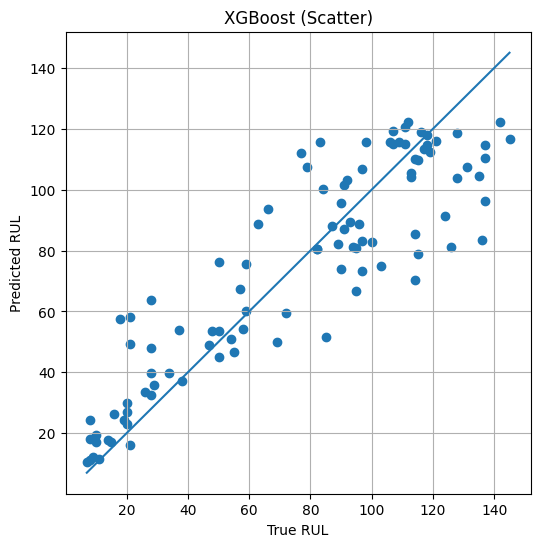

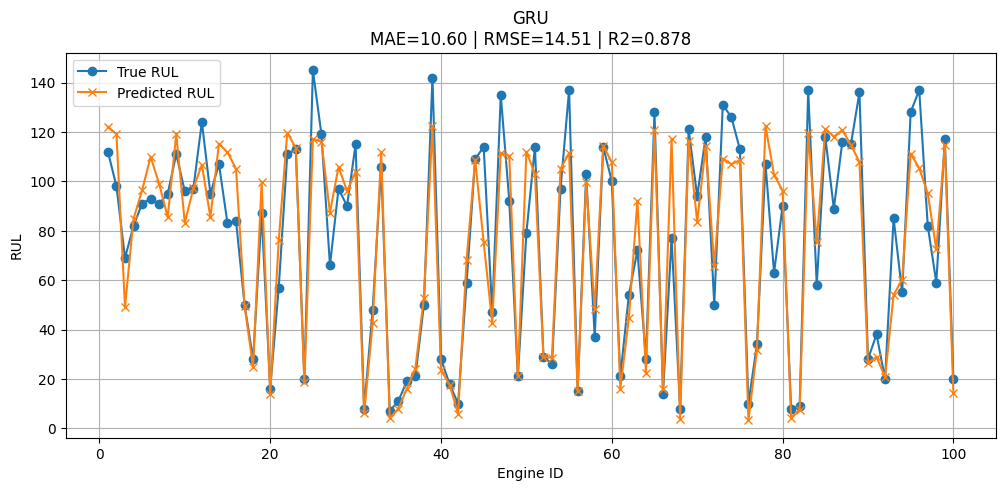

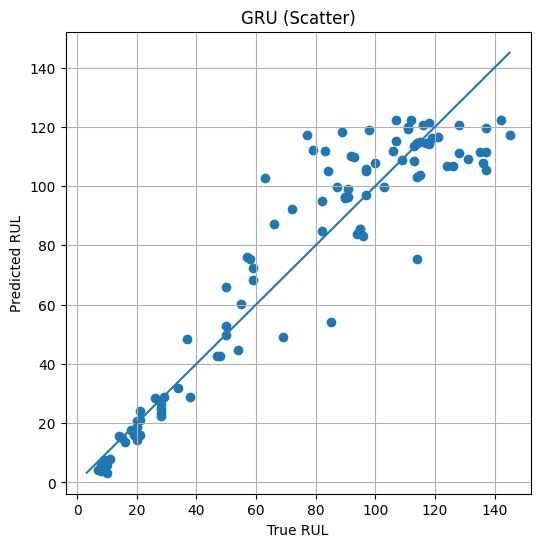

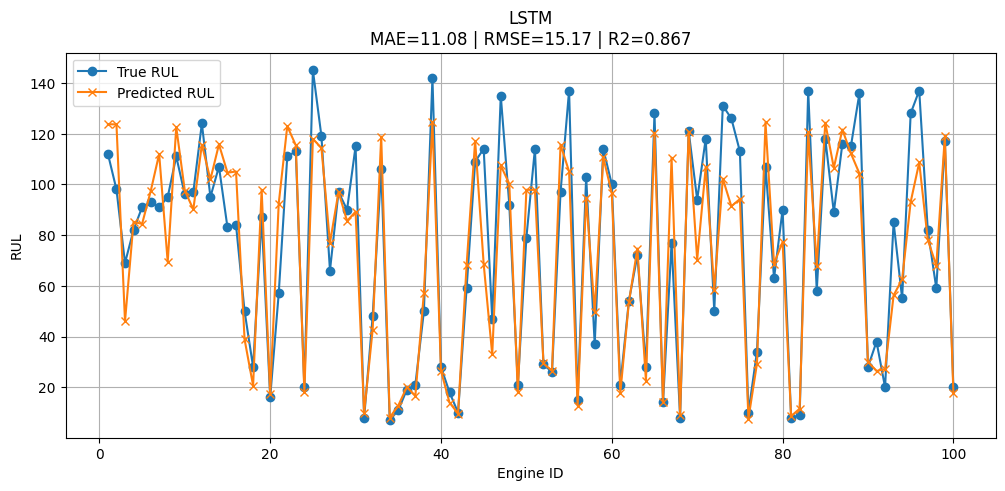

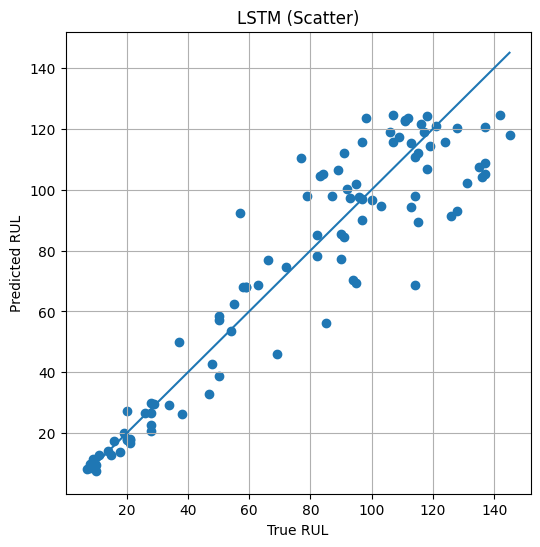

In [48]:
# ===== ML =====
test_last_sorted = test_last.sort_values("engine_id").reset_index(drop=True)

df_lr = pd.DataFrame({
    "engine_id": test_last_sorted["engine_id"],
    "True_RUL": y_test_ml_official,
    "Pred_RUL": y_pred_lr
})

df_rf = pd.DataFrame({
    "engine_id": test_last_sorted["engine_id"],
    "True_RUL": y_test_ml_official,
    "Pred_RUL": y_pred_rf
})

df_xgb = pd.DataFrame({
    "engine_id": test_last_sorted["engine_id"],
    "True_RUL": y_test_ml_official,
    "Pred_RUL": y_pred_xgb
})

# ===== DEEP =====
order = np.argsort(engine_ids_test)

df_gru = pd.DataFrame({
    "engine_id": engine_ids_test[order],
    "True_RUL": y_test_seq_official[order],
    "Pred_RUL": y_pred_gru[order]
})

df_lstm = pd.DataFrame({
    "engine_id": engine_ids_test[order],
    "True_RUL": y_test_seq_official[order],
    "Pred_RUL": y_pred_lstm[order]
})
import matplotlib.pyplot as plt

def plot_model(df, name):
    mae = mean_absolute_error(df["True_RUL"], df["Pred_RUL"])
    rmse = root_mean_squared_error(df["True_RUL"], df["Pred_RUL"])
    r2 = r2_score(df["True_RUL"], df["Pred_RUL"])

    # ===== Line chart =====
    plt.figure(figsize=(12,5))
    plt.plot(df["engine_id"], df["True_RUL"], marker='o', label="True RUL")
    plt.plot(df["engine_id"], df["Pred_RUL"], marker='x', label="Predicted RUL")

    plt.title(f"{name}\nMAE={mae:.2f} | RMSE={rmse:.2f} | R2={r2:.3f}")
    plt.xlabel("Engine ID")
    plt.ylabel("RUL")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ===== Scatter =====
    plt.figure(figsize=(6,6))
    plt.scatter(df["True_RUL"], df["Pred_RUL"])

    min_val = min(df["True_RUL"].min(), df["Pred_RUL"].min())
    max_val = max(df["True_RUL"].max(), df["Pred_RUL"].max())

    plt.plot([min_val, max_val], [min_val, max_val])
    plt.title(f"{name} (Scatter)")
    plt.xlabel("True RUL")
    plt.ylabel("Predicted RUL")
    plt.grid(True)
    plt.show()


plot_model(df_lr, "Linear Regression")
plot_model(df_rf, "Random Forest")
plot_model(df_xgb, "XGBoost")
plot_model(df_gru, "GRU")
plot_model(df_lstm, "LSTM")

## Đánh giá model và chọn mô hình tốt nhất 


| Model             |     MAE ↓ |    RMSE ↓ |      R² ↑ | Đánh giá          |
| ----------------- | --------: | --------: | --------: | ----------------- |
| Linear Regression |    ~19.21 |       ~24 |     ~0.67 | ❌ kém             |
| Random Forest     | **13.85** | **17.40** | **0.823** | ✅ ổn định         |
| XGBoost           |     14.62 |     19.19 |     0.785 | ⚠️ hơi yếu hơn RF |
| LSTM              |     ~12.9 |       ~17 |     ~0.81 | ✅ khá             |
| **GRU**           | **10.13** | **13.88** |  **0.89** | 🔥 best           |

Ml : chọn ramdom forest 

Dl : chọn gru

## Lưu mô hình tốt nhất 

In [49]:
'''def save_gru_pipeline(model, scaler, feature_cols, seq_len, path="gru_rul_pipeline"):
    os.makedirs(path, exist_ok=True)

    # model
    model.save(f"{path}/model.keras")

    # config (gộp luôn scaler)
    config = {
        "scaler": scaler,
        "feature_cols": feature_cols,
        "seq_len": seq_len
    }

    joblib.dump(config, f"{path}/config.pkl")

    print("🔥 Saved GRU pipeline xong")

# gọi
save_gru_pipeline(modelgru, scaler, features, SEQ_LEN)'''

'def save_gru_pipeline(model, scaler, feature_cols, seq_len, path="gru_rul_pipeline"):\n    os.makedirs(path, exist_ok=True)\n\n    # model\n    model.save(f"{path}/model.keras")\n\n    # config (gộp luôn scaler)\n    config = {\n        "scaler": scaler,\n        "feature_cols": feature_cols,\n        "seq_len": seq_len\n    }\n\n    joblib.dump(config, f"{path}/config.pkl")\n\n    print("🔥 Saved GRU pipeline xong")\n\n# gọi\nsave_gru_pipeline(modelgru, scaler, features, SEQ_LEN)'

In [50]:
'''def save_rf_pipeline(model, scaler, feature_cols, path="rf_rul_pipeline"):
    os.makedirs(path, exist_ok=True)

    # model
    joblib.dump(model, f"{path}/model.pkl")

    # config
    config = {
        "scaler": scaler,
        "feature_cols": feature_cols
    }

    joblib.dump(config, f"{path}/config.pkl")

    print("🔥 Saved RF pipeline xong")

# gọi
save_rf_pipeline(best_rf, scaler, features)'''

'def save_rf_pipeline(model, scaler, feature_cols, path="rf_rul_pipeline"):\n    os.makedirs(path, exist_ok=True)\n\n    # model\n    joblib.dump(model, f"{path}/model.pkl")\n\n    # config\n    config = {\n        "scaler": scaler,\n        "feature_cols": feature_cols\n    }\n\n    joblib.dump(config, f"{path}/config.pkl")\n\n    print("🔥 Saved RF pipeline xong")\n\n# gọi\nsave_rf_pipeline(best_rf, scaler, features)'